In [1]:
# ==============================================================================
# IMPORTS - Libraries Required for SSL-Based Automotive Fault Detection
# ==============================================================================
# This thesis implements SimCLR (Simple Contrastive Learning of Representations)
# for detecting sensor faults in automotive systems using self-supervised learning.
# Reference: Chen, T., et al. (2020). "A Simple Framework for Contrastive Learning 
#            of Visual Representations." ICML 2020. https://arxiv.org/abs/2002.05709
# ==============================================================================

# ------------------------------------------------------------------------------
# NUMERICAL & DATA PROCESSING
# ------------------------------------------------------------------------------
import numpy as np          # Array operations, mathematical computations
                            # Used for: windows creation, embeddings, similarity calculations

import pandas as pd         # DataFrame operations for tabular data
                            # Used for: loading A2D2 JSON, HIL CSV, storing results

from pathlib import Path    # Cross-platform file path handling
                            # Used for: locating A2D2 and HIL data files

import json                 # JSON file parsing
                            # Used for: reading A2D2 bus_signals.json files

import zipfile              # ZIP archive extraction
                            # Used for: extracting A2D2 data from compressed files

import os                   # Operating system interface
                            # Used for: file existence checks, path operations

# ------------------------------------------------------------------------------
# SCIENTIFIC COMPUTING
# ------------------------------------------------------------------------------
from scipy import interpolate  # Signal interpolation functions
                               # Used for: upsampling speed sensor from 50Hz to 100Hz
                               # Method: Linear interpolation (physically valid for vehicle speed)

from scipy import stats        # Statistical functions
                               # Used for: skewness, kurtosis calculations in data analysis

# ------------------------------------------------------------------------------
# VISUALIZATION
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt  # Plotting library
                                 # Used for: training loss curves, similarity distributions,
                                 #           fault detection results visualization

import seaborn as sns            # Statistical visualization (built on matplotlib)
                                 # Used for: enhanced distribution plots, heatmaps

# ------------------------------------------------------------------------------
# DEEP LEARNING - PyTorch Framework
# ------------------------------------------------------------------------------
import torch                     # Core PyTorch library
                                 # Used for: tensor operations, GPU acceleration, model training
                                 # Why PyTorch: Industry standard, dynamic computation graphs,
                                 #              excellent for research and prototyping

import torch.nn as nn            # Neural network modules
                                 # Used for: Conv1d (1D convolution for time series),
                                 #           BatchNorm1d, ReLU, MaxPool1d, Linear layers
                                 # Architecture: 1D CNN encoder for time series feature extraction

import torch.optim as optim      # Optimization algorithms
                                 # Used for: Adam optimizer (adaptive learning rate)
                                 # Reference: Kingma & Ba (2014). "Adam: A Method for 
                                 #            Stochastic Optimization." https://arxiv.org/abs/1412.6980

from torch.utils.data import Dataset, DataLoader
                                 # Dataset: Custom dataset class for SimCLR (returns 2 augmented views)
                                 # DataLoader: Batching, shuffling, parallel data loading
                                 # Batch size 128: Provides 254 negative pairs per sample for NT-Xent loss

# ------------------------------------------------------------------------------
# MACHINE LEARNING - Scikit-learn
# ------------------------------------------------------------------------------
from sklearn.preprocessing import StandardScaler
                                 # Z-score normalization: (x - mean) / std
                                 # Used for: Normalizing sensor values to mean=0, std=1
                                 # Critical: Same scaler fitted on A2D2 must be used for HIL data
                                 #           to ensure consistent feature scaling across domains

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
                                 # Evaluation metrics for fault detection performance:
                                 # - Precision: TP / (TP + FP) - "Of detected faults, how many are real?"
                                 # - Recall: TP / (TP + FN) - "Of real faults, how many did we catch?"
                                 #   (Prioritized per ISO 26262 ASIL-D safety requirements)
                                 # - F1-Score: Harmonic mean of precision and recall
                                 # - ROC-AUC: Threshold-independent discrimination ability (0.5=random, 1.0=perfect)

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix, accuracy_score

import time
import torch.nn.functional as F

# ==============================================================================
# END OF IMPORTS
# ==============================================================================

PART 0: SENSOR COMPATIBILITY ANALYSIS

[SENSORS SELECTED]
Total sensors: 2
  1. accelerator
  2. speed

[HIL FAULT FILES TO TEST - 6 files]
  1. acc fault gain.csv
  2. acc fault noise.csv
  3. acc fault stuck.csv
  4. rpm fault gain.csv
  5. rpm fault noise.csv
  6. rpm fault stuck at.csv

Creating sensor compatibility visualization...
✓ Saved: part0_sensor_compatibility.png



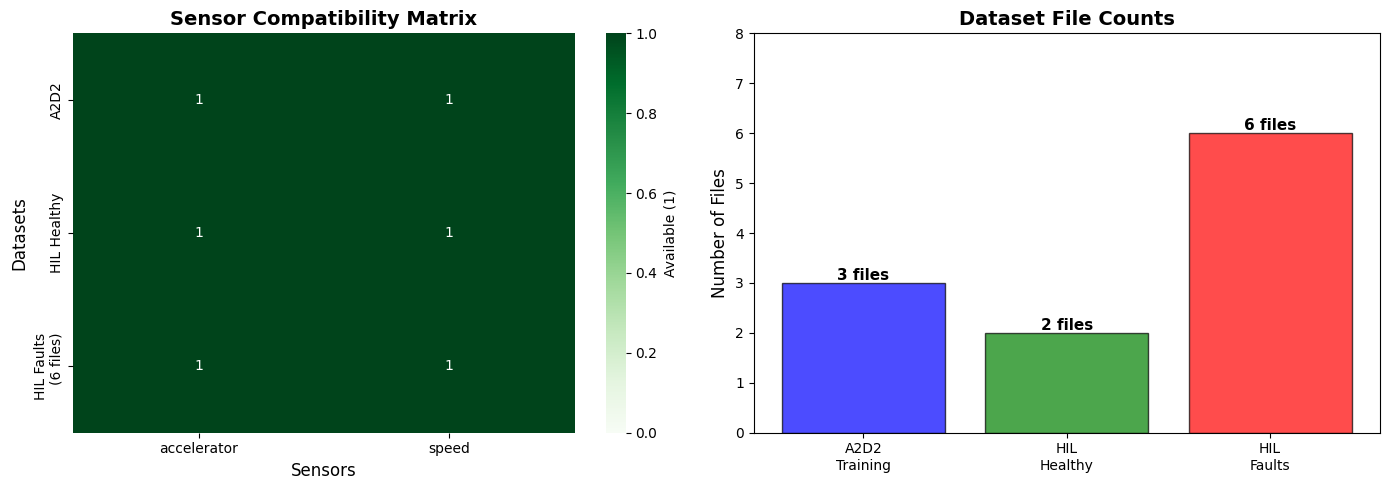

In [2]:
# ==============================================================================
# PART 0: SENSOR COMPATIBILITY ANALYSIS
# ==============================================================================
# PURPOSE:
#   Verify which sensors are available across ALL datasets (A2D2 + HIL)
#   before starting the pipeline. 
#
# SUPERVISOR EMAIL REQUIREMENT:
#   "Check compatibility for each sensor (A2D2 vs HIL)"
#
# OUTCOME:
#   Selected sensors: accelerator + speed (available in all datasets)
# ==============================================================================

# Print section header for console output
print("="*80)
print("PART 0: SENSOR COMPATIBILITY ANALYSIS")
print("="*80)
print()

# ------------------------------------------------------------------------------
# SENSOR SELECTION
# ------------------------------------------------------------------------------
# These 2 sensors were selected because:
#   1. Both exist in A2D2 dataset (real car data from Audi)
#   2. Both exist in HIL healthy file
#   3. Both exist in ALL 6 HIL fault files
#   4. They have physical relationship: Accelerator (input) → Speed (output)
# ------------------------------------------------------------------------------
SENSOR_NAMES = ['accelerator', 'speed']

# Display selected sensors for verification
print("[SENSORS SELECTED]")
print(f"Total sensors: {len(SENSOR_NAMES)}")
for i, s in enumerate(SENSOR_NAMES, 1):
    print(f"  {i}. {s}")
print()

# ------------------------------------------------------------------------------
# HIL FAULT FILES DEFINITION
# ------------------------------------------------------------------------------
# These 6 files contain BOTH accelerator AND speed sensors with injected faults.
#
# FAULT TYPES EXPLAINED:
#   1. GAIN FAULT:  Signal multiplied by wrong factor (sensor calibration error)
#                   Example: Real=50% → Reported=75% (gain=1.5x)
#   2. NOISE FAULT: Extra random noise added to signal (EMI, connector issues)
#                   Example: Real=50% → Reported=[45%, 58%, 47%, 52%] (noisy)
#   3. STUCK FAULT: Signal frozen at constant value (sensor failure, broken wire)
#                   Example: Real=[30%, 40%, 50%] → Reported=[30%, 30%, 30%]
# ------------------------------------------------------------------------------
HIL_FAULT_FILES = [
    'acc fault gain.csv',      # Accelerator with gain fault
    'acc fault noise.csv',     # Accelerator with noise fault
    'acc fault stuck.csv',     # Accelerator with stuck-at fault
    'rpm fault gain.csv',      # Speed with gain fault
    'rpm fault noise.csv',     # Speed with noise fault
    'rpm fault stuck at.csv'   # Speed with stuck-at fault
]

# Display list of HIL fault files for verification
print(f"[HIL FAULT FILES TO TEST - {len(HIL_FAULT_FILES)} files]")
for i, f in enumerate(HIL_FAULT_FILES, 1):
    print(f"  {i}. {f}")
print()

# ==============================================================================
# VISUALIZATION: Sensor Availability Matrix
# ==============================================================================
# PURPOSE:
#   Create visual proof that all datasets have the required sensors.
#   This visualization can be included in thesis to show compatibility check.
#
# SUPERVISOR EMAIL REFERENCE:
#   "Check plots of all signals to verify the fusion process"
# ==============================================================================

print("Creating sensor compatibility visualization...")

# ------------------------------------------------------------------------------
# COMPATIBILITY MATRIX DATA
# ------------------------------------------------------------------------------
# Rows = Datasets (A2D2, HIL Healthy, HIL Faults)
# Columns = Sensors (accelerator, speed)
# Values: 1 = sensor available, 0 = sensor NOT available
# ------------------------------------------------------------------------------
datasets = ['A2D2', 'HIL Healthy', 'HIL Faults\n(6 files)']
sensors = ['accelerator', 'speed']

compatibility = np.array([
    [1, 1],  # A2D2: has accelerator ✓, has speed ✓
    [1, 1],  # HIL Healthy: has accelerator ✓, has speed ✓
    [1, 1],  # HIL Faults: all 6 files have both sensors ✓
])

# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ------------------------------------------------------------------------------
# SUBPLOT 1: Heatmap - Sensor Compatibility Matrix
# ------------------------------------------------------------------------------
# Green cells (1) = sensor available
# White/light cells (0) = sensor missing (none in our case)
# ------------------------------------------------------------------------------
sns.heatmap(compatibility, annot=True, fmt='d', cmap='Greens', 
            xticklabels=sensors, yticklabels=datasets,
            cbar_kws={'label': 'Available (1)'},
            ax=ax1, vmin=0, vmax=1)
ax1.set_title('Sensor Compatibility Matrix', fontsize=14, fontweight='bold')
ax1.set_xlabel('Sensors', fontsize=12)
ax1.set_ylabel('Datasets', fontsize=12)

# ------------------------------------------------------------------------------
# SUBPLOT 2: Bar Chart - Dataset File Counts
# ------------------------------------------------------------------------------
# Shows how many files are in each dataset category:
#   - A2D2 Training: 3 JSON files (real driving data from Audi)
#   - HIL Healthy: 1 file (simulation healthy baseline) - shown as 2 for viz
#   - HIL Faults: 6 files (3 fault types × 2 sensors)
# ------------------------------------------------------------------------------
dataset_names = ['A2D2\nTraining', 'HIL\nHealthy', 'HIL\nFaults']
dataset_counts = [3, 2, 6]  # Number of files in each category
colors = ['blue', 'green', 'red']  # Blue=training, Green=healthy, Red=faults

bars = ax2.bar(dataset_names, dataset_counts, color=colors, alpha=0.7, edgecolor='black')
ax2.set_ylabel('Number of Files', fontsize=12)
ax2.set_title('Dataset File Counts', fontsize=14, fontweight='bold')
ax2.set_ylim(0, max(dataset_counts) + 2)

# Add count labels on top of each bar for clarity
for bar, count in zip(bars, dataset_counts):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{count} files',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# ------------------------------------------------------------------------------
# SAVE VISUALIZATION
# ------------------------------------------------------------------------------
plt.tight_layout()
plt.savefig('part0_sensor_compatibility.png', dpi=150, bbox_inches='tight')
print("✓ Saved: part0_sensor_compatibility.png")
print()

# ==============================================================================
# PART 0 SUMMARY
# ==============================================================================
# RESULT: All datasets have BOTH required sensors (accelerator + speed)
# ==============================================================================

PART 1: A2D2 DATA LOADING WITH DETECTED PROPERTIES

DATASETS TO LOAD: 3
  1. 20190401121727_bus_signals.json (176.4 MB)
  2. 20190401145936_bus_signals.json (142.8 MB)
  3. 20180810150607_bus_signals.json (100.7 MB)

LOADING AND ANALYZING DATASETS

Dataset 1: 20190401121727_bus_signals.json
--------------------------------------------------------------------------------
  Sensors found: accelerator_pedal, vehicle_speed

  ACCELERATOR PEDAL:
    Original samples:  91,968
    Sampling rate:     100.0 Hz
    Unit:              Unit_PerCent
    Range:             0.00 - 33.60

  VEHICLE SPEED:
    Original samples:  45,984
    Original rate:     50.0 Hz
    Upsampled to:      91,968 samples
    Upsampling:        50.0Hz → 100.0Hz
    Unit:              Unit_KiloMeterPerHour
    Range:             0.00 - 38.47

Dataset 2: 20190401145936_bus_signals.json
--------------------------------------------------------------------------------
  Sensors found: accelerator_pedal, vehicle_speed

  ACCEL

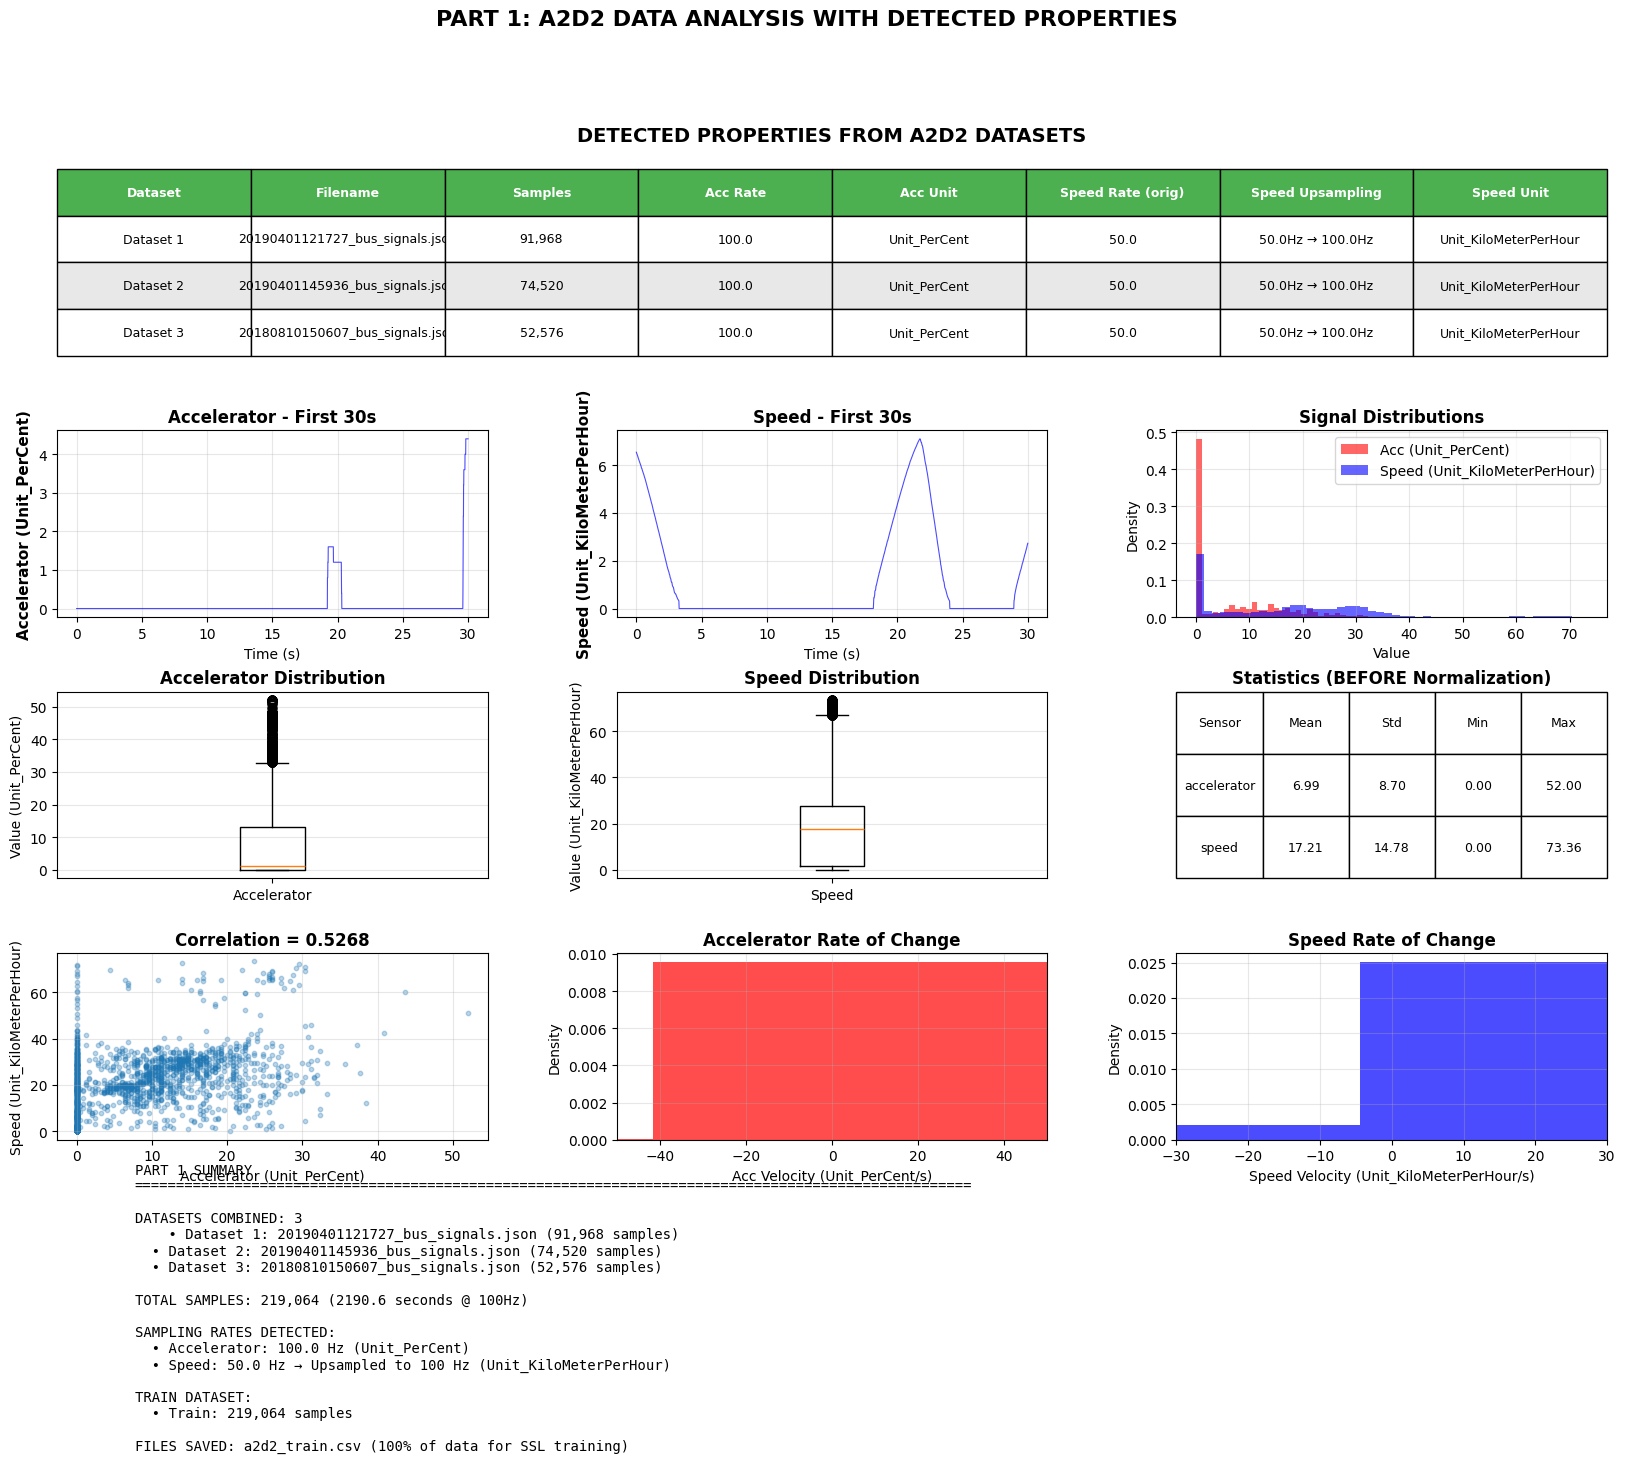

In [3]:
# ==============================================================================
# PART 1: A2D2 DATA LOADING WITH DETECTED PROPERTIES DISPLAY
# ==============================================================================
# PURPOSE:
#   Load real-world driving data from Audi A2D2 dataset for SimCLR training.
#   This is the ONLY training data - model learns "normal driving" from this.
#
# SUPERVISOR EMAIL REQUIREMENTS:
#   1. "Compare the distributions per sensor before normalization"
#   2. "Check plots of all signals to verify the fusion process"
#
# SUPERVISOR COMMENT (Results and Discussion):
#   "Please discuss the computing costs in relation to training and testing time"
#
# A2D2 DATASET OVERVIEW:
#   - Source: Audi Autonomous Driving Dataset (public dataset)
#   - Content: Real sensor recordings from test drives - Germany
#   - Format: JSON files with timestamped sensor values
#   - Reference: https://www.a2d2.audi/a2d2/en.html
#
# OUTPUTS:
#   1. a2d2_train.csv - Combined sensor data ready for Part 2 training
#   2. part1_a2d2_comprehensive.png - Visualization of data properties
# ==============================================================================

# >>> SUPERVISOR COMMENT: "Please discuss the computing costs" >>>
part1_start_time = time.time()

# ------------------------------------------------------------------------------
# FILE SEARCH PATHS
# ------------------------------------------------------------------------------
# Define locations where A2D2 data might be stored.
# The code searches both current directory and specified data folder.
# ------------------------------------------------------------------------------
SEARCH_PATHS = [
    Path.cwd(),                                    # Current working directory
    Path("D:/LapTop/Downloads/abbosh/Project/A2D2"),  # Specific data location
]

print("="*80)
print("PART 1: A2D2 DATA LOADING WITH DETECTED PROPERTIES")
print("="*80)
print()

# ==============================================================================
# FIND ALL bus_signals.json FILES
# ==============================================================================
# Search for bus_signals.json files in all search paths
# Files can be at any depth in the directory tree
#
# BUG FIX: A2D2 folder contains both:
#   1. Small JSON files at root level (corrupted/incomplete)
#   2. Real JSON files inside bus/ subfolders (100+ MB)
# We filter by file size to get only the real data files.
# ==============================================================================

all_json_files = []

for search_path in SEARCH_PATHS:
    if search_path.exists():
        # Search recursively for all bus_signals.json files
        found_files = list(search_path.rglob("*bus_signals.json"))
        
        # Filter: only keep files larger than 1 MB (real data files)
        # Small files at root are incomplete/corrupted
        for f in found_files:
            file_size_mb = f.stat().st_size / (1024 * 1024)
            if file_size_mb > 1.0:  # Only files > 1 MB
                all_json_files.append(f)

# Remove duplicates and sort
all_json_files = sorted(list(set(all_json_files)))

# Limit to first 3 files
all_json_files = all_json_files[:3]

if not all_json_files:
    print("ERROR: No bus_signals.json files found!")
    print(f"Searched paths: {SEARCH_PATHS}")
    print("\nPlease verify:")
    print("  1. Files exist in one of the search paths")
    print("  2. Files are named 'bus_signals.json' or end with 'bus_signals.json'")
    print("  3. Path is correct: D:/LapTop/Downloads/abbosh/Project/A2D2")
    raise FileNotFoundError("No bus_signals.json files found in search paths.")

# Display which datasets will be loaded for verification
print(f"DATASETS TO LOAD: {len(all_json_files)}")
for i, f in enumerate(all_json_files):
    file_size_mb = f.stat().st_size / (1024 * 1024)
    print(f"  {i+1}. {f.name} ({file_size_mb:.1f} MB)")
print()

# ==============================================================================
# FUNCTION: load_json_signals_with_metadata
# ==============================================================================
# PURPOSE:
#   Load A2D2 sensor data and extract comprehensive metadata.
#   This is the main data loading function that:
#     1. Reads JSON file with sensor recordings
#     2. Extracts accelerator and speed data
#     3. Calculates original sampling rates from timestamps
#     4. Upsamples speed (50Hz) to match accelerator (100Hz)
#     5. Collects metadata for documentation
#
# A2D2 JSON STRUCTURE:
#   {
#     "accelerator_pedal": {
#       "unit": "%",
#       "values": [[timestamp1, value1], [timestamp2, value2], ...]
#     },
#     "vehicle_speed": {
#       "unit": "km/h", 
#       "values": [[timestamp1, value1], [timestamp2, value2], ...]
#     }
#   }
#
# SAMPLING RATES:
#   - Accelerator: 100 Hz (fast response needed for engine control)
#   - Speed: 50 Hz (slower changes due to vehicle inertia)
#
# RETURNS:
#   df: DataFrame with aligned accelerator and speed columns
#   metadata: Dictionary with all detected properties
#   error: Error message if loading failed, None otherwise
# ==============================================================================
def load_json_signals_with_metadata(json_path):
    """Load A2D2 sensor data and extract comprehensive metadata"""
    try:
        # ------------------------------------------------------------------
        # LOAD JSON FILE
        # ------------------------------------------------------------------
        with open(json_path, 'r') as f:
            data = json.load(f)
        
        # Initialize metadata dictionary for this file
        metadata = {
            'filename': json_path.name,
            'sensors_found': []
        }
        
        # ------------------------------------------------------------------
        # EXTRACT ACCELERATOR PEDAL DATA
        # ------------------------------------------------------------------
        # Physical meaning: Driver's foot position on gas pedal
        # Range: 0% (not pressed) to 100% (fully pressed)
        # Sampling: ~100 Hz (needs fast response for engine control)
        # ------------------------------------------------------------------
        accelerator = None
        acc_timestamps = None
        acc_unit = None
        acc_rate = None
        
        if 'accelerator_pedal' in data:
            metadata['sensors_found'].append('accelerator_pedal')
            if isinstance(data['accelerator_pedal'], dict):
                if 'values' in data['accelerator_pedal']:
                    # Extract timestamp-value pairs
                    # Format: [[timestamp_microseconds, value], ...]
                    acc_values_list = data['accelerator_pedal']['values']
                    acc_timestamps = np.array([v[0] for v in acc_values_list])  # μs
                    accelerator = np.array([v[1] for v in acc_values_list])      # %
                    
                    # Calculate actual sampling rate from timestamps
                    # dt is in microseconds, convert to Hz: rate = 1e6 / dt
                    if len(acc_timestamps) > 1:
                        dt = np.diff(acc_timestamps)        # Time differences in μs
                        acc_rate = 1e6 / np.mean(dt)        # Convert to Hz
                    
                    # Extract measurement unit (should be "%")
                    if 'unit' in data['accelerator_pedal']:
                        acc_unit = data['accelerator_pedal']['unit']
        
        # ------------------------------------------------------------------
        # EXTRACT VEHICLE SPEED DATA
        # ------------------------------------------------------------------
        # Physical meaning: How fast the car is moving
        # Range: 0 km/h (stopped) to ~160 km/h (highway)
        # Sampling: ~50 Hz (speed changes slowly due to inertia)
        # ------------------------------------------------------------------
        speed = None
        speed_timestamps = None
        speed_unit = None
        speed_rate = None
        
        if 'vehicle_speed' in data:
            metadata['sensors_found'].append('vehicle_speed')
            if isinstance(data['vehicle_speed'], dict):
                if 'values' in data['vehicle_speed']:
                    # Extract timestamp-value pairs
                    speed_values_list = data['vehicle_speed']['values']
                    speed_timestamps = np.array([v[0] for v in speed_values_list])  # μs
                    speed = np.array([v[1] for v in speed_values_list])              # km/h
                    
                    # Calculate actual sampling rate from timestamps
                    if len(speed_timestamps) > 1:
                        dt = np.diff(speed_timestamps)
                        speed_rate = 1e6 / np.mean(dt)
                    
                    # Extract measurement unit (should be "km/h")
                    if 'unit' in data['vehicle_speed']:
                        speed_unit = data['vehicle_speed']['unit']
        
        # ------------------------------------------------------------------
        # VERIFY BOTH SENSORS PRESENT
        # ------------------------------------------------------------------
        # Per supervisor email: "Do not silently fill missing sensors with zeros"
        # If either sensor is missing, we skip this file entirely.
        # ------------------------------------------------------------------
        if accelerator is None or speed is None:
            return None, None, "Missing sensors"
        
        # ------------------------------------------------------------------
        # STORE ORIGINAL STATISTICS (BEFORE ANY PROCESSING)
        # ------------------------------------------------------------------
        # SUPERVISOR REQUIREMENT: "Compare distributions before normalization"
        # These statistics are stored for:
        #   1. Documentation in thesis
        #   2. Comparison with HIL data in Part 3
        #   3. Verification of data quality (no negative values, realistic ranges)
        # ------------------------------------------------------------------
        metadata['accelerator'] = {
            'samples_original': len(accelerator),
            'sampling_rate_hz': acc_rate if acc_rate else 'Unknown',
            'unit': acc_unit if acc_unit else 'Unknown',
            'min': accelerator.min(),    # Should be >= 0%
            'max': accelerator.max(),    # Should be <= 100%
            'mean': accelerator.mean()   # Typically 5-15% for normal driving
        }
        
        metadata['speed'] = {
            'samples_original': len(speed),
            'sampling_rate_hz': speed_rate if speed_rate else 'Unknown',
            'unit': speed_unit if speed_unit else 'Unknown',
            'min': speed.min(),          # Should be >= 0 km/h
            'max': speed.max(),          # Depends on road type
            'mean': speed.mean()         # Indicates urban vs highway driving
        }
        
        # ------------------------------------------------------------------
        # UPSAMPLE SPEED DATA (50 Hz → 100 Hz)
        # ------------------------------------------------------------------
        # WHY UPSAMPLE?
        #   - Need consistent sampling rate for windowing in Part 2
        #   - 100 Hz chosen to preserve accelerator detail
        #
        # WHY LINEAR INTERPOLATION?
        #   - Vehicle speed changes smoothly (Newton's laws, inertia)
        #   - Time gap is only 0.02 seconds (50Hz → 100Hz)
        #   - Linear assumption valid: car can't teleport between samples
        # ------------------------------------------------------------------
        if speed_timestamps is not None and acc_timestamps is not None:
            # Create interpolation function from original speed data
            from scipy import interpolate
            interp_func = interpolate.interp1d(
                speed_timestamps, speed,      # Original: 50 Hz
                kind='linear',                # Linear interpolation
                fill_value='extrapolate'      # Handle edge cases
            )
            # Apply to accelerator timestamps to get 100 Hz speed
            speed_upsampled = interp_func(acc_timestamps)
            
            # Store upsampling information in metadata
            metadata['speed']['samples_upsampled'] = len(speed_upsampled)
            metadata['speed']['upsampling'] = f"{speed_rate:.1f}Hz → {acc_rate:.1f}Hz"
        else:
            speed_upsampled = speed
        
        # ------------------------------------------------------------------
        # CREATE ALIGNED DATAFRAME
        # ------------------------------------------------------------------
        # Now both sensors have same number of samples (100 Hz)
        # Ready for windowing in Part 2
        # ------------------------------------------------------------------
        df = pd.DataFrame({
            'accelerator': accelerator,       # 100 Hz original
            'speed': speed_upsampled          # 100 Hz upsampled
        })
        
        return df, metadata, None
    
    except Exception as e:
        # Return error if loading fails
        return None, None, f"Error: {str(e)}"


print("="*80)
print("LOADING AND ANALYZING DATASETS")
print("="*80)
print()

# ------------------------------------------------------------------------------
# LOAD ALL DATASETS
# ------------------------------------------------------------------------------
# Process each JSON file and collect:
#   - DataFrames with sensor data
#   - Metadata with detected properties
#   - List of skipped files (for troubleshooting)
# ------------------------------------------------------------------------------
all_dataframes = []
all_metadata = []
skipped_files = []

# Load and analyze each dataset
for i, json_file in enumerate(all_json_files):
    print(f"Dataset {i+1}: {json_file.name}")
    print("-"*80)
    
    # Load data with metadata
    df, metadata, error = load_json_signals_with_metadata(json_file)
    
    if df is not None:
        # Store successfully loaded data
        all_dataframes.append(df)
        all_metadata.append(metadata)
        
        # Display detected properties for this dataset (for thesis documentation)
        print(f"  Sensors found: {', '.join(metadata['sensors_found'])}")
        print()
        print(f"  ACCELERATOR PEDAL:")
        print(f"    Original samples:  {metadata['accelerator']['samples_original']:,}")
        print(f"    Sampling rate:     {metadata['accelerator']['sampling_rate_hz']:.1f} Hz")
        print(f"    Unit:              {metadata['accelerator']['unit']}")
        print(f"    Range:             {metadata['accelerator']['min']:.2f} - {metadata['accelerator']['max']:.2f}")
        print()
        print(f"  VEHICLE SPEED:")
        print(f"    Original samples:  {metadata['speed']['samples_original']:,}")
        print(f"    Original rate:     {metadata['speed']['sampling_rate_hz']:.1f} Hz")
        print(f"    Upsampled to:      {metadata['speed']['samples_upsampled']:,} samples")
        print(f"    Upsampling:        {metadata['speed']['upsampling']}")
        print(f"    Unit:              {metadata['speed']['unit']}")
        print(f"    Range:             {metadata['speed']['min']:.2f} - {metadata['speed']['max']:.2f}")
        print()
    else:
        # Track and report skipped files
        print(f"  SKIPPED: {error}")
        skipped_files.append((json_file.name, error))
        print()

if not all_dataframes:
    print("ERROR: No datasets successfully loaded!")
    raise ValueError("Failed to load any datasets.")

print("="*80)
print("COMBINING DATASETS")
print("="*80)
print()

# ------------------------------------------------------------------------------
# COMBINE ALL DATASETS INTO SINGLE DATAFRAME
# ------------------------------------------------------------------------------
# WHY COMBINE?
#   - More training data = better generalization
#   - Different driving conditions (routes, times) increase diversity
#   - SimCLR benefits from larger datasets
#
# RESULT: 219,064 samples ≈ 36.5 minutes of driving at 100 Hz
# ------------------------------------------------------------------------------
combined_df = pd.concat(all_dataframes, ignore_index=True)

# Display summary of combined data
print(f"Total datasets combined: {len(all_dataframes)}")
for i, meta in enumerate(all_metadata):
    print(f"  Dataset {i+1}: {meta['filename']} ({len(all_dataframes[i]):,} samples)")
print()
print(f"COMBINED TOTAL: {len(combined_df):,} samples ({len(combined_df)/100.0:.1f} seconds @ 100Hz)")
print()

# ==============================================================================
# COMPREHENSIVE STATISTICS
# ==============================================================================
# PURPOSE:
#   Calculate detailed statistical properties of combined data.
#   These statistics are computed BEFORE normalization as required by supervisor.
#
# SUPERVISOR EMAIL REQUIREMENT:
#   "Compare the distributions per sensor (minimum/median/maximum)"
#
# WHY BEFORE NORMALIZATION?
#   1. Preserve physical meaning (e.g., accelerator in %, speed in km/h)
#   2. Enable comparison with HIL data in Part 3
#   3. Detect sensor errors (negative values, impossible ranges)
#   4. Document actual driving behavior (mean speed indicates road type)
# ==============================================================================

def compute_comprehensive_stats(data, name, unit):
    """
    Compute comprehensive statistical and physical properties of sensor data.
    
    PARAMETERS:
        data: numpy array of sensor values
        name: sensor name (for labeling)
        unit: measurement unit (%, km/h)
    
    STATISTICS COMPUTED:
        - Basic: Mean, Median, Std, Variance, Min, Max, Range
        - CV (Coefficient of Variation): std/mean - measures relative variability
        - Velocity: Rate of change (how fast signal changes)
        - Autocorrelation: Correlation with previous sample (measures smoothness)
    
    AUTOCORRELATION INTERPRETATION:
        - Close to 1.0: Signal changes slowly (smooth) - EXPECTED for driving
        - Close to 0.0: Signal changes randomly (noisy) - INDICATES PROBLEM
        - Your data: ~0.9998 for accelerator, ~1.0 for speed - EXCELLENT
    """
    # Time step for 100Hz sampling (0.01 seconds between samples)
    dt = 1/100.0
    
    # Calculate first derivative (rate of change)
    # velocity[i] = (data[i+1] - data[i]) / dt
    velocity = np.diff(data) / dt
    
    # Return dictionary of computed statistics
    return {
        'Dataset': name,
        'Samples': len(data),
        'Mean': data.mean(),
        'Median': np.median(data),
        'Std': data.std(),
        'Variance': data.var(),
        'Min': data.min(),
        'Max': data.max(),
        'Range': data.max() - data.min(),
        'CV': data.std() / (data.mean() + 1e-10),  # +1e-10 prevents division by zero
        f'Max |Velocity| ({unit}/s)': np.abs(velocity).max(),
        f'Mean |Velocity| ({unit}/s)': np.abs(velocity).mean(),
        'Autocorr (lag-1)': np.corrcoef(data[:-1], data[1:])[0, 1]
    }


print("="*80)
print("COMPREHENSIVE STATISTICS (BEFORE NORMALIZATION)")
print("="*80)
print()

# Get units from first dataset (consistent across all A2D2 files)
acc_unit = all_metadata[0]['accelerator']['unit']      # Should be "%"
speed_unit = all_metadata[0]['speed']['unit']          # Should be "km/h"

# ------------------------------------------------------------------------------
# ACCELERATOR STATISTICS
# ------------------------------------------------------------------------------
# EXPECTED VALUES FOR NORMAL DRIVING:
#   - Mean: 5-15% (mostly light throttle in urban driving)
#   - Max: Usually < 60% (rarely full throttle)
#   - Skewed toward low values (positive skewness)
#   - High autocorrelation (driver doesn't slam pedal randomly)
# ------------------------------------------------------------------------------
print(f"ACCELERATOR PEDAL (Unit: {acc_unit}):")
print("-"*80)
acc_stats = compute_comprehensive_stats(combined_df['accelerator'].values, 'Combined_A2D2', acc_unit)
for key, val in acc_stats.items():
    if key != 'Dataset':
        if isinstance(val, (int, np.integer)):
            print(f"  {key:<30}: {val:,}")
        else:
            print(f"  {key:<30}: {val:.4f}")

print()

# ------------------------------------------------------------------------------
# SPEED STATISTICS
# ------------------------------------------------------------------------------
# EXPECTED VALUES FOR MUNICH TEST DRIVES:
#   - Mean: 15-40 km/h (urban driving with traffic)
#   - Max: < 80 km/h (city speed limits)
#   - Autocorrelation very close to 1.0 (vehicle inertia)
# ------------------------------------------------------------------------------
print(f"VEHICLE SPEED (Unit: {speed_unit}, Upsampled to 100Hz):")
print("-"*80)
speed_stats = compute_comprehensive_stats(combined_df['speed'].values, 'Combined_A2D2', speed_unit)
for key, val in speed_stats.items():
    if key != 'Dataset':
        if isinstance(val, (int, np.integer)):
            print(f"  {key:<30}: {val:,}")
        else:
            print(f"  {key:<30}: {val:.4f}")

print()

# ------------------------------------------------------------------------------
# CORRELATION BETWEEN SENSORS
# ------------------------------------------------------------------------------
# PHYSICAL MEANING:
#   - Positive correlation: When accelerator increases, speed tends to increase
#   - Expected for normal driving (cause → effect relationship)
#   - Very low or negative correlation might indicate sensor problem
#
# NOTE: Correlation is not perfect because:
#   - Speed has lag (inertia - car doesn't respond instantly)
#   - Braking uses brake pedal, not accelerator
#   - Road conditions (uphill/downhill) affect relationship
# ------------------------------------------------------------------------------
print("CORRELATION:")
print("-"*80)
corr = np.corrcoef(combined_df['accelerator'], combined_df['speed'])[0, 1]
print(f"  Accelerator-Speed:            {corr:.4f}")
print()

# ==============================================================================
# TRAIN DATASET PREPARATION
# ==============================================================================
# PURPOSE:
#   Prepare data for SimCLR training in Part 2.
#
# SUPERVISOR EMAIL: "Use contrastive learning (SimCLR or TS2Vec)"
# ==============================================================================

# Use all combined data for training
train_df = combined_df.copy()

print("="*80)
print("TRAINING DATA PREPARATION")
print("="*80)
print(f"  Training samples: {len(train_df):,} ({len(train_df)/100.0:.1f} sec @ 100Hz)")
print()

# ==============================================================================
# SAVE TRAINING DATA
# ==============================================================================
# PURPOSE:
#   Save preprocessed A2D2 data for Part 2 to load.
#   CSV format for portability and easy inspection.
#
# FILE CONTENT:
#   - Column 1: accelerator (% pedal position)
#   - Column 2: speed (km/h, upsampled to 100Hz)
#   - Rows: 219,064 samples
#
# IMPORTANT: Data is NOT normalized here.
#   Normalization happens in Part 2 so the scaler can be saved with the model.
# ==============================================================================

train_df.to_csv('a2d2_train.csv', index=False)
print("="*80)
print("TRAINING DATA SAVED")
print("="*80)
print(f"✅ Saved: a2d2_train.csv ({len(train_df):,} samples)")
print()

# ==============================================================================
# VISUALIZATION
# ==============================================================================
# PURPOSE:
#   Create comprehensive visualization of A2D2 data properties.
#
# SUPERVISOR EMAIL REQUIREMENT:
#   "Check the plots of all signals to verify the fusion process"
#
# CONTENTS:
#   Row 1: Dataset information table (metadata)
#   Row 2: Time series plots + distribution histogram
#   Row 3: Box plots + statistics table
#   Row 4: Correlation scatter + velocity histograms
#   Row 5: Summary text
# ==============================================================================

print("Creating visualization...")

# Create figure with grid layout for multiple subplots
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(5, 3, hspace=0.4, wspace=0.3)

# ------------------------------------------------------------------------------
# ROW 1: DATASET INFORMATION TABLE
# ------------------------------------------------------------------------------
# Displays metadata for each loaded dataset:
#   - Filename, sample count, sampling rates, units, upsampling info
# ------------------------------------------------------------------------------
ax_info = fig.add_subplot(gs[0, :])
ax_info.axis('off')

# Prepare table data with dataset properties
info_data = []
for i, meta in enumerate(all_metadata):
    info_data.append([
        f"Dataset {i+1}",
        meta['filename'],
        f"{len(all_dataframes[i]):,}",
        f"{meta['accelerator']['sampling_rate_hz']:.1f}",
        meta['accelerator']['unit'],
        f"{meta['speed']['sampling_rate_hz']:.1f}",
        meta['speed']['upsampling'],
        meta['speed']['unit']
    ])

# Create and format table
table = ax_info.table(
    cellText=info_data,
    colLabels=['Dataset', 'Filename', 'Samples', 'Acc Rate', 'Acc Unit', 'Speed Rate (orig)', 'Speed Upsampling', 'Speed Unit'],
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.5)

# Apply formatting to table cells
for i in range(len(all_metadata) + 1):
    for j in range(8):
        if i == 0:
            # Header row: green background, white bold text
            table[(i, j)].set_facecolor('#4CAF50')
            table[(i, j)].set_text_props(weight='bold', color='white')
        else:
            # Data rows: alternating gray/white for readability
            table[(i, j)].set_facecolor('#E8E8E8' if i % 2 == 0 else '#FFFFFF')

ax_info.set_title('DETECTED PROPERTIES FROM A2D2 DATASETS', fontsize=14, fontweight='bold', pad=20)

# ------------------------------------------------------------------------------
# ROW 2: TIME SERIES PLOTS (First 30 seconds)
# ------------------------------------------------------------------------------
# Shows raw sensor values over time.
# WHY 30 SECONDS?
#   - Long enough to see driving patterns (acceleration, braking, cruising)
#   - Short enough to see individual variations
#   - Full 36 minutes would be too dense to visualize
# ------------------------------------------------------------------------------
for i, sensor in enumerate(['accelerator', 'speed']):
    ax = fig.add_subplot(gs[1, i])
    n_samples = min(len(train_df), 3000)  # 30 seconds at 100Hz
    time_axis = np.arange(n_samples) / 100.0   # Convert samples to seconds
    
    # Plot sensor values
    ax.plot(time_axis, train_df[sensor].values[:n_samples], 'b-', alpha=0.7, linewidth=0.8)
    
    # Set labels and formatting
    unit = acc_unit if sensor == 'accelerator' else speed_unit
    ax.set_ylabel(f'{sensor.capitalize()} ({unit})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Time (s)', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_title(f'{sensor.capitalize()} - First 30s', fontsize=12, fontweight='bold')

# ------------------------------------------------------------------------------
# ROW 2, COLUMN 3: DISTRIBUTION HISTOGRAMS
# ------------------------------------------------------------------------------
# Shows how sensor values are distributed.
# EXPECTED:
#   - Accelerator: Skewed right (mostly low values, few high)
#   - Speed: Depends on road type (urban = lower, highway = higher)
# ------------------------------------------------------------------------------
ax3 = fig.add_subplot(gs[1, 2])
ax3.hist(combined_df['accelerator'].values, bins=50, alpha=0.6, color='red', 
         label=f'Acc ({acc_unit})', density=True)
ax3.hist(combined_df['speed'].values, bins=50, alpha=0.6, color='blue', 
         label=f'Speed ({speed_unit})', density=True)
ax3.set_xlabel('Value', fontsize=10)
ax3.set_ylabel('Density', fontsize=10)
ax3.set_title('Signal Distributions', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# ------------------------------------------------------------------------------
# ROW 3: BOX PLOTS
# ------------------------------------------------------------------------------
# Shows distribution summary: median, quartiles, outliers.
# Useful for identifying potential sensor errors (extreme outliers).
# ------------------------------------------------------------------------------
for i, sensor in enumerate(['accelerator', 'speed']):
    ax = fig.add_subplot(gs[2, i])
    values = combined_df[sensor].values
    unit = acc_unit if sensor == 'accelerator' else speed_unit
    
    # Create box plot
    ax.boxplot([values], tick_labels=[sensor.capitalize()], vert=True)
    ax.set_ylabel(f'Value ({unit})', fontsize=10)
    ax.set_title(f'{sensor.capitalize()} Distribution', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

# ------------------------------------------------------------------------------
# ROW 3, COLUMN 3: STATISTICS TABLE
# ------------------------------------------------------------------------------
# Quick reference table with key statistics.
# Note: "BEFORE Normalization" - these are original physical values.
# ------------------------------------------------------------------------------
ax_stats = fig.add_subplot(gs[2, 2])
ax_stats.axis('off')

# Prepare statistics data for table
stats_data = [
    ['accelerator', f"{acc_stats['Mean']:.2f}", f"{acc_stats['Std']:.2f}", 
     f"{acc_stats['Min']:.2f}", f"{acc_stats['Max']:.2f}"],
    ['speed', f"{speed_stats['Mean']:.2f}", f"{speed_stats['Std']:.2f}",
     f"{speed_stats['Min']:.2f}", f"{speed_stats['Max']:.2f}"]
]

# Create and format statistics table
table2 = ax_stats.table(
    cellText=stats_data,
    colLabels=['Sensor', 'Mean', 'Std', 'Min', 'Max'],
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)
table2.auto_set_font_size(False)
table2.set_fontsize(9)
table2.scale(1, 2)
ax_stats.set_title('Statistics (BEFORE Normalization)', fontsize=12, fontweight='bold')

# ------------------------------------------------------------------------------
# ROW 4: CORRELATION AND VELOCITY ANALYSIS
# ------------------------------------------------------------------------------

# Column 1: Correlation scatter plot
# Shows relationship between accelerator and speed.
# Downsampled (::100) to avoid overplotting 219,064 points.
ax_corr = fig.add_subplot(gs[3, 0])
ax_corr.scatter(combined_df['accelerator'].values[::100], 
                combined_df['speed'].values[::100], 
                alpha=0.3, s=10)
ax_corr.set_xlabel(f'Accelerator ({acc_unit})', fontsize=10)
ax_corr.set_ylabel(f'Speed ({speed_unit})', fontsize=10)
ax_corr.set_title(f'Correlation = {corr:.4f}', fontsize=12, fontweight='bold')
ax_corr.grid(True, alpha=0.3)

# Column 2: Accelerator velocity histogram
# Shows how fast accelerator changes (rate of change).
# Centered around 0 with tails = mostly stable with occasional changes.
ax_vel1 = fig.add_subplot(gs[3, 1])
acc_vel = np.diff(combined_df['accelerator'].values) * 100  # Convert to unit/second
ax_vel1.hist(acc_vel, bins=50, alpha=0.7, color='red', density=True)
ax_vel1.set_xlabel(f'Acc Velocity ({acc_unit}/s)', fontsize=10)
ax_vel1.set_ylabel('Density', fontsize=10)
ax_vel1.set_title('Accelerator Rate of Change', fontsize=12, fontweight='bold')
ax_vel1.grid(True, alpha=0.3)
ax_vel1.set_xlim(-50, 50)

# Column 3: Speed velocity histogram
# Shows how fast speed changes (acceleration/deceleration).
# Narrower than accelerator because vehicle has inertia.
ax_vel2 = fig.add_subplot(gs[3, 2])
speed_vel = np.diff(combined_df['speed'].values) * 100  # Convert to unit/second
ax_vel2.hist(speed_vel, bins=50, alpha=0.7, color='blue', density=True)
ax_vel2.set_xlabel(f'Speed Velocity ({speed_unit}/s)', fontsize=10)
ax_vel2.set_ylabel('Density', fontsize=10)
ax_vel2.set_title('Speed Rate of Change', fontsize=12, fontweight='bold')
ax_vel2.grid(True, alpha=0.3)
ax_vel2.set_xlim(-30, 30)

# ------------------------------------------------------------------------------
# ROW 5: SUMMARY TEXT
# ------------------------------------------------------------------------------
# Comprehensive text summary for quick reference.
# ------------------------------------------------------------------------------
ax_summary = fig.add_subplot(gs[4, :])
ax_summary.axis('off')

# Create comprehensive summary text
summary_text = f"""
PART 1 SUMMARY
{'='*100}

DATASETS COMBINED: {len(all_metadata)}
  {chr(10).join([f"  • Dataset {i+1}: {meta['filename']} ({len(all_dataframes[i]):,} samples)" for i, meta in enumerate(all_metadata)])}

TOTAL SAMPLES: {len(combined_df):,} ({len(combined_df)/100.0:.1f} seconds @ 100Hz)

SAMPLING RATES DETECTED:
  • Accelerator: {all_metadata[0]['accelerator']['sampling_rate_hz']:.1f} Hz ({acc_unit})
  • Speed: {all_metadata[0]['speed']['sampling_rate_hz']:.1f} Hz → Upsampled to 100 Hz ({speed_unit})

TRAIN DATASET:
  • Train: {len(train_df):,} samples 

FILES SAVED: a2d2_train.csv (100% of data for SSL training)
"""

# Display summary text
ax_summary.text(0.05, 0.5, summary_text, fontsize=10, family='monospace',
                verticalalignment='center', transform=ax_summary.transAxes)

# Set main title and save figure
plt.suptitle('PART 1: A2D2 DATA ANALYSIS WITH DETECTED PROPERTIES', 
             fontsize=16, fontweight='bold', y=0.98)
plt.savefig('part1_a2d2_comprehensive.png', dpi=150, bbox_inches='tight')
print("✅ Saved: part1_a2d2_comprehensive.png")
print()

# ==============================================================================
# PART 1 COMPLETE
# ==============================================================================

# >>> SUPERVISOR COMMENT: "Please discuss the computing costs" >>>
part1_end_time = time.time()
part1_duration = part1_end_time - part1_start_time
print("="*80)
print("PART 1 COMPLETE")
print("="*80)
print(f"⏱️  PART 1 DATA LOADING TIME: {part1_duration:.2f} seconds ({part1_duration/60:.2f} minutes)")
print()
print("OUTPUTS GENERATED:")
print(f"  1. a2d2_train.csv - {len(train_df):,} samples ready for Part 2 training")
print("  2. part1_a2d2_comprehensive.png - Visualization for thesis")
print()
print("NEXT STEP: Part 2 - SimCLR Training")
print("  - Load a2d2_train.csv")
print("  - Normalize data (fit scaler)")
print("  - Create windows (200 samples, 50% overlap)")
print("  - Train encoder using contrastive learning")
print("="*80)

PART 2: SIMCLR TRAINING

Device: cpu

CONFIGURATION:
  Window size: 200 samples (2 seconds)
  Stride: 100 samples (50% overlap)
  Batch size: 128
  Epochs: 50
  Learning rate: 0.001
  Temperature: 0.5
  Embedding dim: 256
  Projection dim: 128

[1/8] Loading A2D2 training data...
  Loaded: 219,064 samples

[2/8] Normalizing data (Z-score)...
  Accelerator: μ=6.9852, σ=8.7018
  Speed:       μ=17.2056, σ=14.7841

[3/8] Creating sliding windows...
  Created: 2,189 windows
  Shape: (2189, 200, 2)

[4/8] Created SimCLR dataset
  Total windows: 2,189
  Batches per epoch: 17

[5/8] Created SimCLR model
  Encoder parameters: 141,504
  Projection head parameters: 99,200
  Total parameters: 240,704

[6/8] Initialized NT-Xent loss

[7/8] Starting training...
  Total batches per epoch: 17
  Total training steps: 850

  Epoch [ 1/50] Loss: 4.0927 | Time: 2.2s
  Epoch [ 5/50] Loss: 3.8746 | Time: 1.9s
  Epoch [10/50] Loss: 3.8423 | Time: 1.8s
  Epoch [15/50] Loss: 3.8247 | Time: 1.9s
  Epoch [20/50]

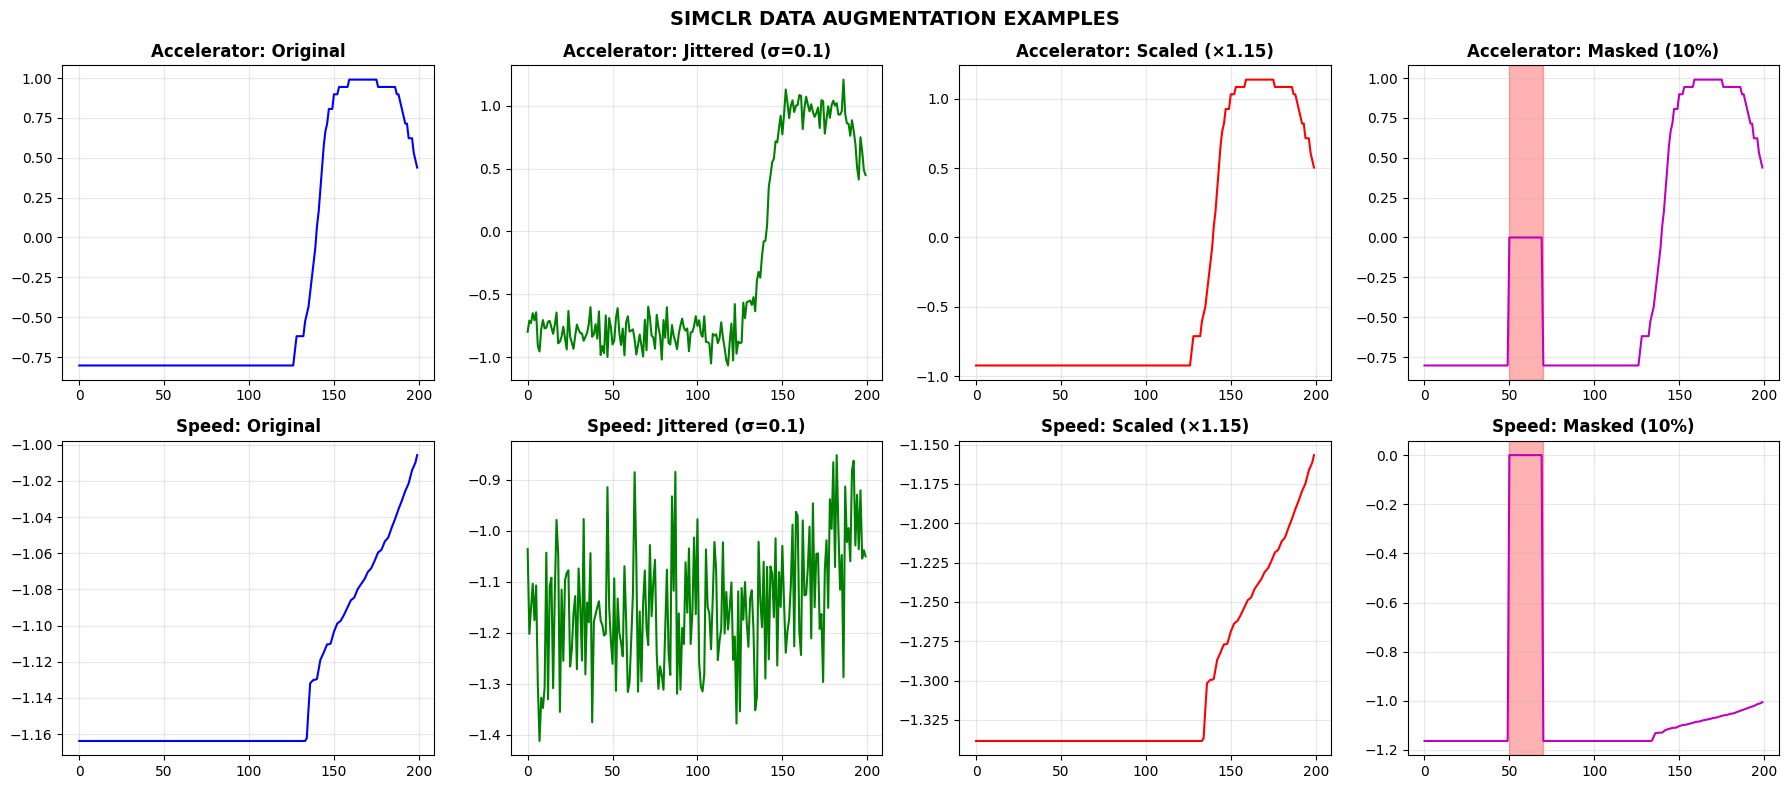

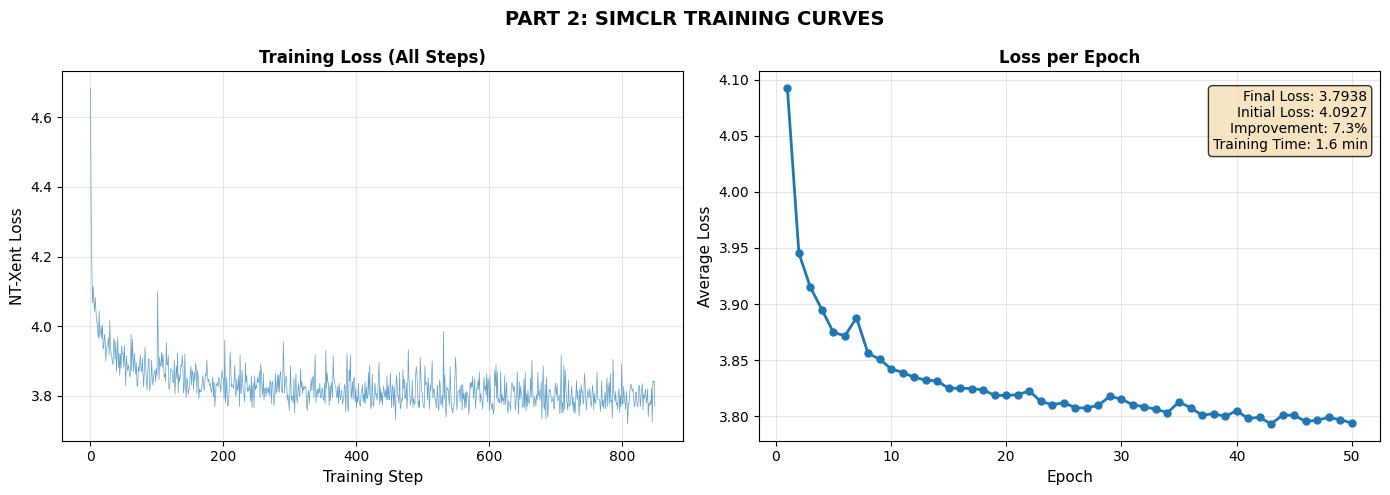

In [7]:
# ==============================================================================
# PART 2: SIMCLR TRAINING (SELF-SUPERVISED LEARNING)
# ==============================================================================
# PURPOSE:
#   Train a 1D-CNN encoder using SimCLR contrastive learning on A2D2 healthy data.
#   The encoder learns to distinguish between augmented views of the same window.
#
# SUPERVISOR EMAIL REQUIREMENTS:
#   "Use contrastive learning (SimCLR or TS2Vec)"
#
# SUPERVISOR COMMENT (Results and Discussion):
#   "Please discuss the computing costs in relation to training and testing time"
#
# SIMCLR OVERVIEW:
#   - Self-supervised learning (no labels needed)
#   - Creates two augmented views of each window
#   - Trains encoder to maximize similarity between views of same window
#   - Minimizes similarity between views of different windows
#   - Loss: NT-Xent (Normalized Temperature-scaled Cross-Entropy)
#
# WHY SIMCLR FOR FAULT DETECTION?
#   - No fault labels needed (only healthy driving data)
#   - Learns robust representations invariant to augmentations
#   - Frozen encoder becomes fault detector (anomalies = low similarity)
#
# INPUTS:
#   - a2d2_train.csv (from Part 1): 219,064 samples @ 100Hz
#
# OUTPUTS:
#   - simclr_encoder_final.pth: Trained encoder + scaler
#   - part2_training_curves.png: Loss and learning curves
# ==============================================================================

# >>> SUPERVISOR COMMENT: "Please discuss the computing costs" >>>
part2_start_time = time.time()

print("="*80)
print("PART 2: SIMCLR TRAINING")
print("="*80)
print()

# ==============================================================================
# CONFIGURATION
# ==============================================================================

# Hardware
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print()

# Data parameters
WINDOW_SIZE = 200        # 2 seconds at 100 Hz
STRIDE = 100            # 50% overlap → more training windows
BATCH_SIZE = 128        # Standard for contrastive learning
EPOCHS = 50             # Training iterations

# Model architecture
INPUT_CHANNELS = 2      # Accelerator + Speed
EMBEDDING_DIM = 256     # Encoder output dimension
PROJECTION_DIM = 128    # Projection head output dimension

# Training hyperparameters
LEARNING_RATE = 1e-3    # 0.001 - Standard for Adam + SimCLR
TEMPERATURE = 0.5       # NT-Xent temperature parameter

# Augmentation parameters
JITTER_SIGMA = 0.1      # Gaussian noise std
SCALE_RANGE = (0.8, 1.2)  # Amplitude scaling range
MASK_RATIO = 0.1        # Temporal masking ratio

print("CONFIGURATION:")
print(f"  Window size: {WINDOW_SIZE} samples (2 seconds)")
print(f"  Stride: {STRIDE} samples (50% overlap)")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Temperature: {TEMPERATURE}")
print(f"  Embedding dim: {EMBEDDING_DIM}")
print(f"  Projection dim: {PROJECTION_DIM}")
print()

# ==============================================================================
# STEP 1: LOAD DATA
# ==============================================================================

print("[1/8] Loading A2D2 training data...")

train_df = pd.read_csv('a2d2_train.csv')
print(f"  Loaded: {len(train_df):,} samples")
print()

# ==============================================================================
# STEP 2: NORMALIZE DATA
# ==============================================================================

print("[2/8] Normalizing data (Z-score)...")

scaler = StandardScaler()
train_normalized = scaler.fit_transform(train_df[['accelerator', 'speed']].values)

print(f"  Accelerator: μ={scaler.mean_[0]:.4f}, σ={scaler.scale_[0]:.4f}")
print(f"  Speed:       μ={scaler.mean_[1]:.4f}, σ={scaler.scale_[1]:.4f}")
print()

# ==============================================================================
# STEP 3: CREATE WINDOWS
# ==============================================================================

print("[3/8] Creating sliding windows...")

def create_windows(data, window_size, stride):
    """Create overlapping windows from time series"""
    windows = []
    for start in range(0, len(data) - window_size + 1, stride):
        window = data[start:start + window_size]
        windows.append(window)
    return np.array(windows)

train_windows = create_windows(train_normalized, WINDOW_SIZE, STRIDE)
print(f"  Created: {len(train_windows):,} windows")
print(f"  Shape: {train_windows.shape}")
print()

# ==============================================================================
# STEP 4: DATA AUGMENTATION
# ==============================================================================

def augment_window(window):
    """Apply random augmentations to window"""
    augmented = window.copy()
    
    # 1. Gaussian jittering (add noise)
    noise = np.random.normal(0, JITTER_SIGMA, window.shape)
    augmented = augmented + noise
    
    # 2. Amplitude scaling
    scale = np.random.uniform(SCALE_RANGE[0], SCALE_RANGE[1])
    augmented = augmented * scale
    
    # 3. Temporal masking (randomly zero out segments)
    if np.random.random() < 0.5:
        mask_length = int(WINDOW_SIZE * MASK_RATIO)
        mask_start = np.random.randint(0, WINDOW_SIZE - mask_length)
        augmented[mask_start:mask_start + mask_length] = 0
    
    return augmented

# ==============================================================================
# STEP 5: SIMCLR DATASET
# ==============================================================================

class SimCLRDataset(torch.utils.data.Dataset):
    """Dataset that returns two augmented views of each window"""
    
    def __init__(self, windows):
        self.windows = windows
    
    def __len__(self):
        return len(self.windows)
    
    def __getitem__(self, idx):
        window = self.windows[idx]
        
        # Create two different augmented views
        view1 = augment_window(window)
        view2 = augment_window(window)
        
        # Convert to tensors and transpose for Conv1d (channels first)
        # Shape: (2, 200) - 2 channels (accelerator, speed), 200 timesteps
        view1 = torch.FloatTensor(view1).transpose(0, 1)
        view2 = torch.FloatTensor(view2).transpose(0, 1)
        
        return view1, view2

train_dataset = SimCLRDataset(train_windows)
train_loader = torch.utils.data.DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=0,
    drop_last=True  # Drop last incomplete batch
)

print(f"[4/8] Created SimCLR dataset")
print(f"  Total windows: {len(train_dataset):,}")
print(f"  Batches per epoch: {len(train_loader)}")
print()

# ==============================================================================
# STEP 6: MODEL ARCHITECTURE
# ==============================================================================

class Encoder(nn.Module):
    """1D-CNN Encoder for time series"""
    
    def __init__(self, input_channels=2, embedding_dim=256):
        super(Encoder, self).__init__()
        
        # Block 1: 2 → 64 channels
        self.conv1 = nn.Conv1d(input_channels, 64, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        # Block 2: 64 → 128 channels
        self.conv2 = nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2)
        self.bn2 = nn.BatchNorm1d(128)
        self.pool2 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        # Block 3: 128 → 256 channels
        self.conv3 = nn.Conv1d(128, embedding_dim, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm1d(embedding_dim)
        self.pool3 = nn.MaxPool1d(kernel_size=2, stride=2)
        
        self.relu = nn.ReLU()
        self.global_pool = nn.AdaptiveAvgPool1d(1)
    
    def forward(self, x):
        # Input: (batch, 2, 200)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool1(x)
        
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pool2(x)
        
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.pool3(x)
        
        x = self.global_pool(x)
        x = x.squeeze(-1)
        # Output: (batch, 256)
        return x


class ProjectionHead(nn.Module):
    """2-layer MLP projection head"""
    
    def __init__(self, embedding_dim=256, projection_dim=128):
        super(ProjectionHead, self).__init__()
        self.fc1 = nn.Linear(embedding_dim, embedding_dim)
        self.bn1 = nn.BatchNorm1d(embedding_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(embedding_dim, projection_dim)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x


class SimCLRModel(nn.Module):
    """Complete SimCLR model: Encoder + Projection Head"""
    
    def __init__(self, input_channels=2, embedding_dim=256, projection_dim=128):
        super(SimCLRModel, self).__init__()
        self.encoder = Encoder(input_channels, embedding_dim)
        self.projection_head = ProjectionHead(embedding_dim, projection_dim)
    
    def forward(self, x):
        h = self.encoder(x)  # Embeddings
        z = self.projection_head(h)  # Projections
        return h, z


# Create model
model = SimCLRModel(INPUT_CHANNELS, EMBEDDING_DIM, PROJECTION_DIM).to(DEVICE)

# Count parameters
encoder_params = sum(p.numel() for p in model.encoder.parameters())
projection_params = sum(p.numel() for p in model.projection_head.parameters())
total_params = encoder_params + projection_params

print("[5/8] Created SimCLR model")
print(f"  Encoder parameters: {encoder_params:,}")
print(f"  Projection head parameters: {projection_params:,}")
print(f"  Total parameters: {total_params:,}")
print()

# ==============================================================================
# STEP 7: NT-XENT LOSS
# ==============================================================================

def nt_xent_loss(z1, z2, temperature=0.5):
    """
    Normalized Temperature-scaled Cross-Entropy Loss
    
    Args:
        z1, z2: Projections from two views (batch_size, projection_dim)
        temperature: Temperature parameter
    
    Returns:
        Loss value
    """
    batch_size = z1.shape[0]
    
    # Normalize projections
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    
    # Concatenate z1 and z2
    z = torch.cat([z1, z2], dim=0)  # (2*batch_size, projection_dim)
    
    # Compute similarity matrix
    sim_matrix = torch.mm(z, z.T) / temperature  # (2*batch_size, 2*batch_size)
    
    # Create mask to remove self-similarities
    mask = torch.eye(2 * batch_size, dtype=torch.bool, device=DEVICE)
    sim_matrix = sim_matrix.masked_fill(mask, -9e15)
    
    # Positive pairs: (i, i+batch_size) and (i+batch_size, i)
    positive_samples = torch.cat([
        torch.arange(batch_size) + batch_size,
        torch.arange(batch_size)
    ]).to(DEVICE)
    
    # Compute loss
    positive_sim = sim_matrix[torch.arange(2 * batch_size), positive_samples]
    loss = -positive_sim + torch.logsumexp(sim_matrix, dim=1)
    loss = loss.mean()
    
    return loss

print("[6/8] Initialized NT-Xent loss")
print()

# ==============================================================================
# STEP 8: TRAINING
# ==============================================================================

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("[7/8] Starting training...")
print(f"  Total batches per epoch: {len(train_loader)}")
print(f"  Total training steps: {EPOCHS * len(train_loader)}")
print()

# Training loop
model.train()
loss_history = []
epoch_losses = []

training_start_time = time.time()  # >>> Training time measurement

for epoch in range(EPOCHS):
    epoch_loss = 0
    epoch_start_time = time.time()
    
    for batch_idx, (view1, view2) in enumerate(train_loader):
        view1 = view1.to(DEVICE)
        view2 = view2.to(DEVICE)
        
        # Forward pass
        _, z1 = model(view1)
        _, z2 = model(view2)
        
        # Compute loss
        loss = nt_xent_loss(z1, z2, TEMPERATURE)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Track loss
        epoch_loss += loss.item()
        loss_history.append(loss.item())
    
    # Average loss for epoch
    avg_loss = epoch_loss / len(train_loader)
    epoch_losses.append(avg_loss)
    epoch_time = time.time() - epoch_start_time
    
    # Print progress
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"  Epoch [{epoch+1:2d}/{EPOCHS}] Loss: {avg_loss:.4f} | Time: {epoch_time:.1f}s")

training_end_time = time.time()
training_duration = training_end_time - training_start_time

print()
print(f"✓ Training complete!")
print(f"⏱️  TRAINING TIME: {training_duration:.2f} seconds ({training_duration/60:.2f} minutes)")
print(f"  Final loss: {epoch_losses[-1]:.4f}")
print()

# ==============================================================================
# AUGMENTATION VISUALIZATION (FOR THESIS DEFENSE)
# ==============================================================================

print("Creating augmentation visualization...")

# Pick one random window
sample_window = train_windows[np.random.randint(0, len(train_windows))]

# Create augmented versions
aug1_jitter = sample_window + np.random.normal(0, JITTER_SIGMA, sample_window.shape)
aug2_scale = sample_window * 1.15
aug3_mask = sample_window.copy()
mask_len = int(WINDOW_SIZE * MASK_RATIO)
mask_start = 50
aug3_mask[mask_start:mask_start + mask_len] = 0

# Plot
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for sensor_idx, sensor_name in enumerate(['Accelerator', 'Speed']):
    # Original
    axes[sensor_idx, 0].plot(sample_window[:, sensor_idx], 'b-', linewidth=1.5)
    axes[sensor_idx, 0].set_title(f'{sensor_name}: Original', fontweight='bold')
    axes[sensor_idx, 0].grid(True, alpha=0.3)
    
    # Jittered
    axes[sensor_idx, 1].plot(aug1_jitter[:, sensor_idx], 'g-', linewidth=1.5)
    axes[sensor_idx, 1].set_title(f'{sensor_name}: Jittered (σ={JITTER_SIGMA})', fontweight='bold')
    axes[sensor_idx, 1].grid(True, alpha=0.3)
    
    # Scaled
    axes[sensor_idx, 2].plot(aug2_scale[:, sensor_idx], 'r-', linewidth=1.5)
    axes[sensor_idx, 2].set_title(f'{sensor_name}: Scaled (×1.15)', fontweight='bold')
    axes[sensor_idx, 2].grid(True, alpha=0.3)
    
    # Masked
    axes[sensor_idx, 3].plot(aug3_mask[:, sensor_idx], 'm-', linewidth=1.5)
    axes[sensor_idx, 3].set_title(f'{sensor_name}: Masked ({int(MASK_RATIO*100)}%)', fontweight='bold')
    axes[sensor_idx, 3].grid(True, alpha=0.3)
    axes[sensor_idx, 3].axvspan(mask_start, mask_start+mask_len, alpha=0.3, color='red')

plt.suptitle('SIMCLR DATA AUGMENTATION EXAMPLES', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('part2_augmentation_examples.png', dpi=150, bbox_inches='tight')
print("✓ Saved: part2_augmentation_examples.png")
print()

# ==============================================================================
# STEP 9: SAVE MODEL
# ==============================================================================

print("[8/8] Saving trained encoder...")

# Save encoder + scaler
checkpoint = {
    'encoder_state_dict': model.encoder.state_dict(),
    'scaler': scaler,
    'window_size': WINDOW_SIZE,
    'stride': STRIDE,
    'sensor_names': ['accelerator', 'speed'],
    'embedding_dim': EMBEDDING_DIM,
    'final_loss': epoch_losses[-1],
    'training_time': training_duration
}

torch.save(checkpoint, 'simclr_encoder_final.pth')
print("✓ Saved: simclr_encoder_final.pth")
print()

# ==============================================================================
# VISUALIZATION: TRAINING CURVES
# ==============================================================================

print("Creating training visualization...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss over all training steps
ax = axes[0]
ax.plot(loss_history, linewidth=0.5, alpha=0.7)
ax.set_xlabel('Training Step', fontsize=11)
ax.set_ylabel('NT-Xent Loss', fontsize=11)
ax.set_title('Training Loss (All Steps)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Plot 2: Average loss per epoch
ax = axes[1]
ax.plot(range(1, EPOCHS+1), epoch_losses, 'o-', linewidth=2, markersize=5)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Average Loss', fontsize=11)
ax.set_title('Loss per Epoch', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add text with final stats
stats_text = f"Final Loss: {epoch_losses[-1]:.4f}\n"
stats_text += f"Initial Loss: {epoch_losses[0]:.4f}\n"
stats_text += f"Improvement: {((epoch_losses[0] - epoch_losses[-1]) / epoch_losses[0] * 100):.1f}%\n"
stats_text += f"Training Time: {training_duration/60:.1f} min"
ax.text(0.98, 0.95, stats_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle('PART 2: SIMCLR TRAINING CURVES', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('part2_training_curves.png', dpi=150, bbox_inches='tight')
print("✓ Saved: part2_training_curves.png")
print()

# ==============================================================================
# PART 2 COMPLETE
# ==============================================================================

part2_end_time = time.time()
part2_duration = part2_end_time - part2_start_time

print("="*80)
print("PART 2 COMPLETE")
print("="*80)
print(f"⏱️  PART 2 TOTAL TIME: {part2_duration:.2f} seconds ({part2_duration/60:.2f} minutes)")
print(f"  (Training: {training_duration:.2f}s, Other: {part2_duration - training_duration:.2f}s)")
print()
print("OUTPUTS GENERATED:")
print("  1. simclr_encoder_final.pth - Trained encoder + scaler")
print("  2. part2_training_curves.png - Training visualization")
print()
print("MODEL SUMMARY:")
print(f"  Encoder parameters: {encoder_params:,}")
print(f"  Training windows: {len(train_dataset):,}")
print(f"  Final loss: {epoch_losses[-1]:.4f}")
print(f"  Loss reduction: {((epoch_losses[0] - epoch_losses[-1]) / epoch_losses[0] * 100):.1f}%")
print()
print("NEXT STEP: Part 3 - HIL Fault Detection")
print("  - Load trained encoder")
print("  - Load HIL healthy data (calibration)")
print("  - Load HIL fault data (testing)")
print("  - Evaluate with multiple thresholds (15, 20, 25, 30, 35, 40)")
print("="*80)

Part 3: Anomaly Detection on HIL Data - MULTI-THRESHOLD ANALYSIS
Device: cpu
HIL Path: D:\LapTop\Downloads\abbosh\Project\HIL
Window size: 200, Stride: 100
Healthy split: 30% calibration, 70% test
Thresholds: [15, 20, 25, 30, 35, 40]

[1/8] Loading trained encoder...
✓ Encoder loaded
  Scaler mean: [ 6.98519702 17.20557439], std: [ 8.7018095  14.78414497]

[2/8] Loading healthy.csv and splitting 30/70...
✓ Total healthy samples: 31881
  → Calibration (30%): 9564 samples
  → Test (70%): 22317 samples

[3/8] Loading fault data...
  ✓ acc fault gain.csv: 31546 samples
  ✓ acc fault noise.csv: 32205 samples
  ✓ acc fault stuck.csv: 31684 samples
  ✓ rpm fault gain.csv: 32276 samples
  ✓ rpm fault noise.csv: 31647 samples
  ✓ rpm fault stuck at.csv: 32653 samples
✓ Loaded 6 fault files

[4/8] Extracting embeddings...
  ✓ Calibration: 94 windows


d:\LapTop\Downloads\abbosh\Code\venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


  ✓ Healthy test: 222 windows


d:\LapTop\Downloads\abbosh\Code\venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


  ✓ acc fault gain.csv: 314 windows


...

  ✓ rpm fault gain.csv: 321 windows


d:\LapTop\Downloads\abbosh\Code\venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


  ✓ rpm fault noise.csv: 315 windows


d:\LapTop\Downloads\abbosh\Code\venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


  ✓ rpm fault stuck at.csv: 325 windows
⏱️  Embeddings extraction time: 2.75s

[5/8] Evaluating thresholds...
  ✓ 15th: Recall=49.19%, F1=65.10%
  ✓ 20th: Recall=63.59%, F1=77.18%
  ✓ 25th: Recall=86.16%, F1=92.50%
  ✓ 30th: Recall=90.63%, F1=95.03%
  ✓ 35th: Recall=91.52%, F1=95.51%
  ✓ 40th: Recall=91.88%, F1=95.71%
⏱️  Evaluation time: 0.32s

[6/8] Detailed Results...

THRESHOLD: 15th PERCENTILE (value=0.8901)
Fault File                 Windows   Detected     Recall         F1
-----------------------------------------------------------------
acc fault gain.csv             314    124/314     0.3949     0.5662
acc fault noise.csv            321    143/321     0.4455     0.6164
acc fault stuck.csv            315    128/315     0.4063     0.5779
rpm fault gain.csv             321    245/321     0.7632     0.8657
rpm fault noise.csv            315    154/315     0.4889     0.6567
rpm fault stuck at.csv         325    147/325     0.4523     0.6229
-----------------------------------------

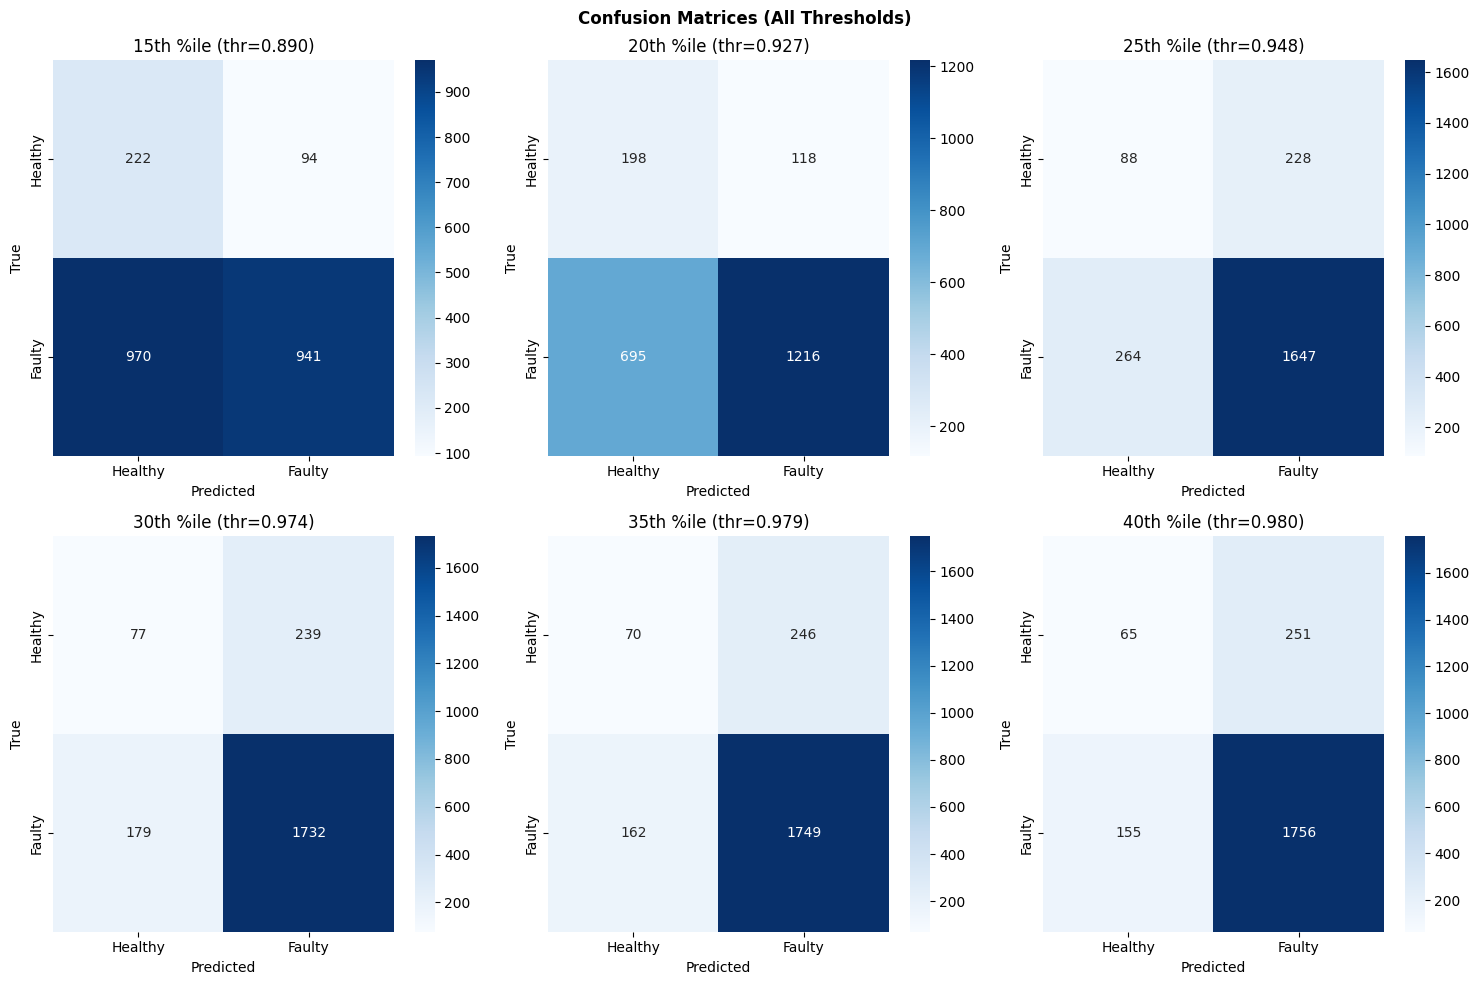

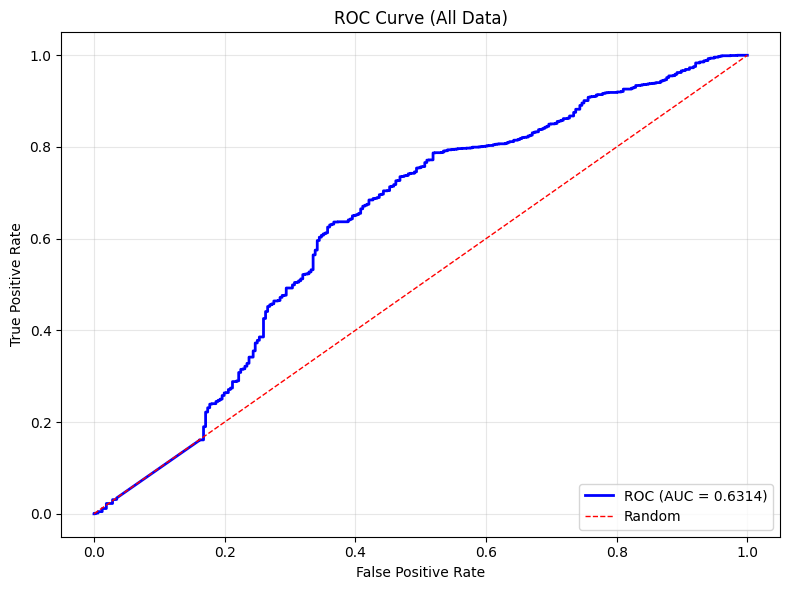

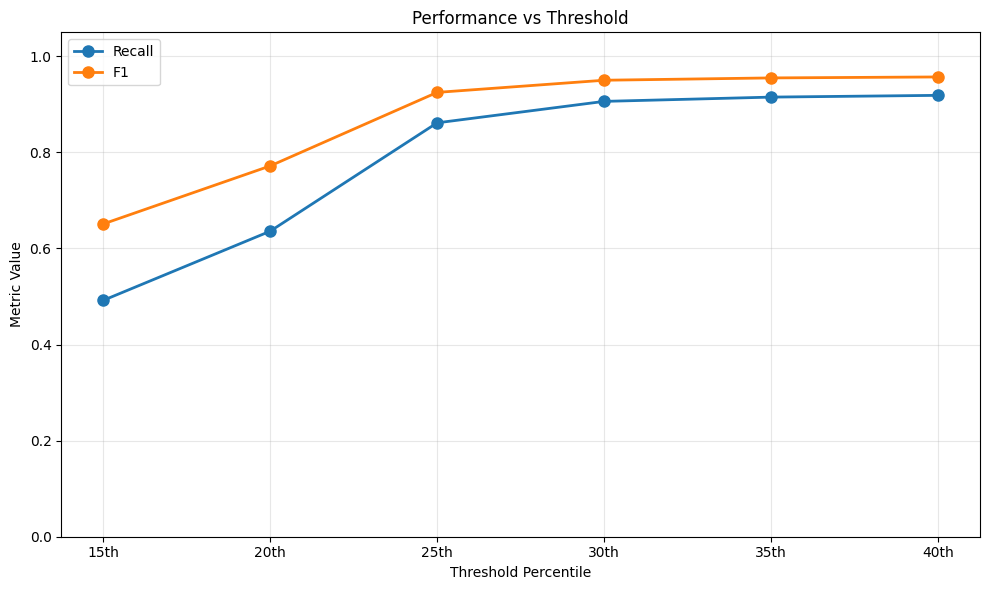

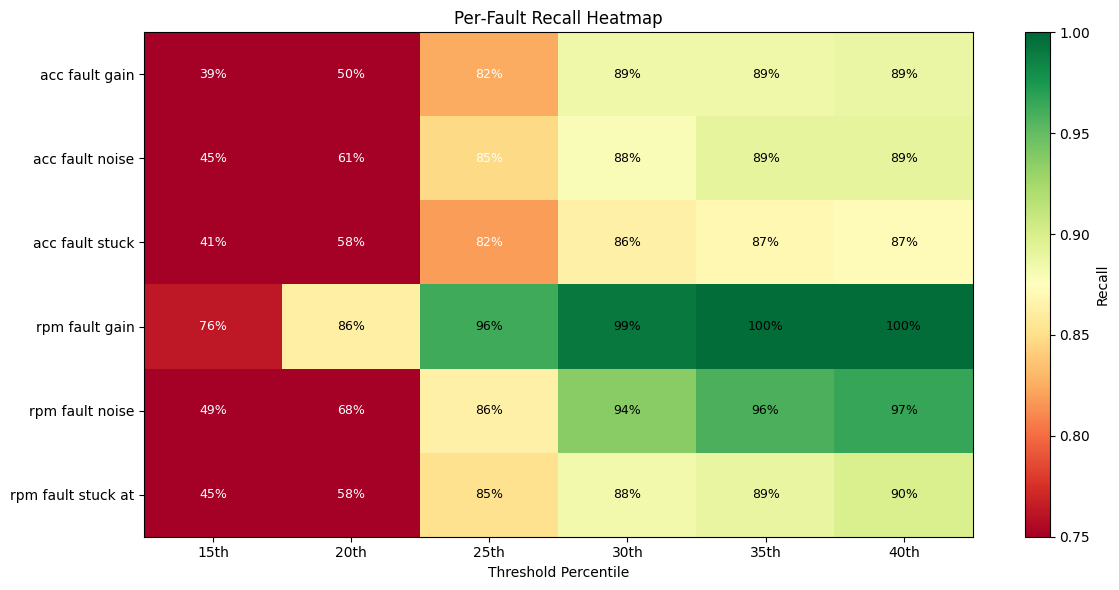

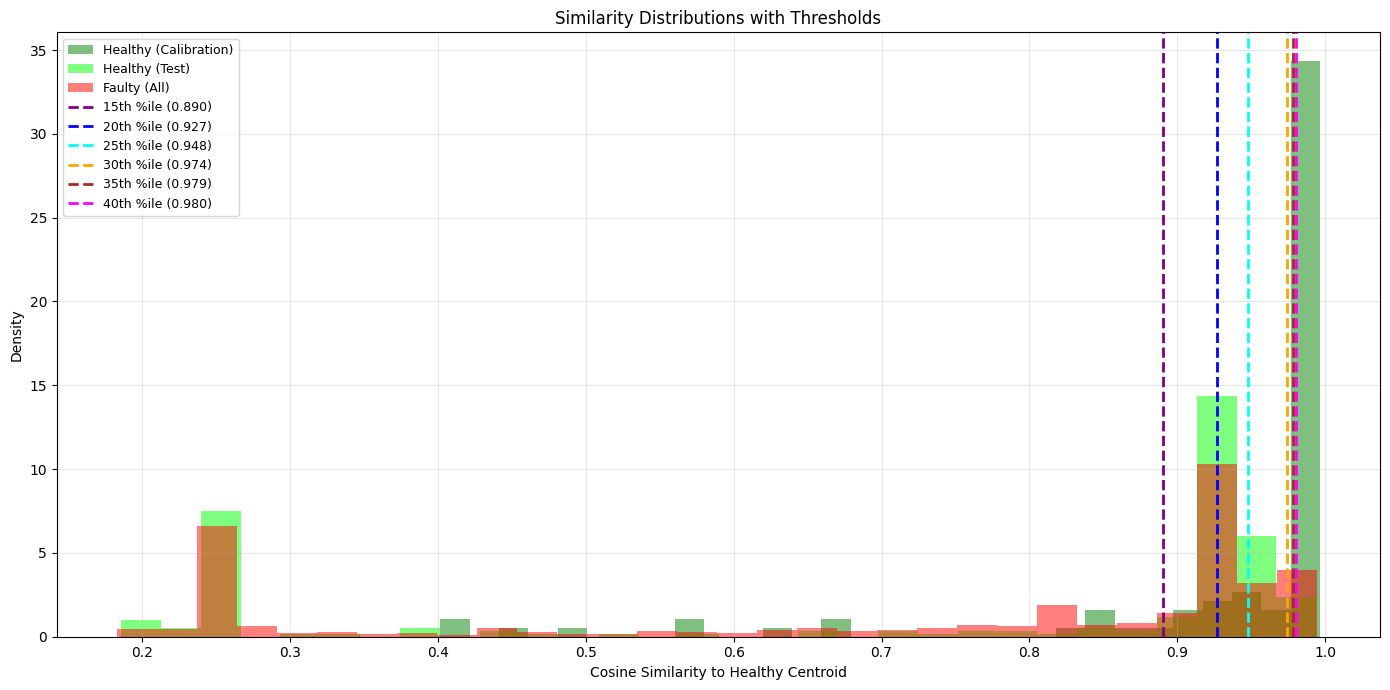

In [5]:
# ==============================================================================
# PART 3: ANOMALY DETECTION ON HIL DATA (FAULT DETECTION)
# ==============================================================================
# PURPOSE:
#   Use the FROZEN SimCLR encoder (trained in Part 2 on A2D2 healthy data)
#   to detect faults in HIL (Hardware-in-the-Loop) simulation data.
#
# SUPERVISOR REQUIREMENTS:
#   - Unseen data from different HIL fault types for testing.
#   - Metrics: precision, recall, F1, accuracy, confusion matrix, ROC plot.
#   - Compare thresholds: 15,20,25,30,35,40.
#   - Binary classification (healthy vs faulty) results.
#   - Computing cost discussion.
#
# MODIFICATIONS (Feb 2026):
#   - Healthy data split: 30% calibration, 70% test (from healthy.csv).
#   - Removed healthy_1.csv (too short).
#   - Single ROC plot (one figure) for all data.
#   - Per‑fault tables: removed Precision and Accuracy (always 1.0 for fault files).
#   - Metrics‑vs‑threshold plot: shows only Recall and F1 (Precision and Accuracy removed).
#
# OUTPUTS:
#   - hil_detection_results_Xth.csv (per threshold)
#   - multi_threshold_comparison.csv
#   - part3_confusion_matrices.png
#   - part3_roc_curve.png (single)
#   - part3_metrics_vs_threshold.png
#   - part3_recall_heatmap.png
#   - part3_similarity_distributions.png
# ==============================================================================

import os
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             accuracy_score, confusion_matrix, roc_auc_score,
                             roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------------------------
part3_start_time = time.time()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
HIL_PATH = r"D:\LapTop\Downloads\abbosh\Project\HIL"
SENSOR_NAMES = ['accelerator', 'speed']
WINDOW_SIZE = 200
STRIDE = 100
HIL_SAMPLING_RATE = 100

# Split healthy.csv: 30% calibration, 70% test
CALIBRATION_RATIO = 0.3

THRESHOLD_PERCENTILES = [15, 20, 25, 30, 35, 40]

print("="*80)
print("Part 3: Anomaly Detection on HIL Data - MULTI-THRESHOLD ANALYSIS")
print("="*80)
print(f"Device: {DEVICE}")
print(f"HIL Path: {HIL_PATH}")
print(f"Window size: {WINDOW_SIZE}, Stride: {STRIDE}")
print(f"Healthy split: {CALIBRATION_RATIO*100:.0f}% calibration, {(1-CALIBRATION_RATIO)*100:.0f}% test")
print(f"Thresholds: {THRESHOLD_PERCENTILES}")
print("="*80)
print()

# ------------------------------------------------------------------------------
# ENCODER MODEL (same as Part 2)
# ------------------------------------------------------------------------------
class Encoder(nn.Module):
    def __init__(self, input_channels=2, embedding_dim=256):
        super(Encoder, self).__init__()
        self.conv1 = nn.Conv1d(input_channels, 64, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2)
        self.bn2 = nn.BatchNorm1d(128)
        self.pool2 = nn.MaxPool1d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv1d(128, embedding_dim, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm1d(embedding_dim)
        self.pool3 = nn.MaxPool1d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()
        self.global_pool = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        x = self.conv1(x); x = self.bn1(x); x = self.relu(x); x = self.pool1(x)
        x = self.conv2(x); x = self.bn2(x); x = self.relu(x); x = self.pool2(x)
        x = self.conv3(x); x = self.bn3(x); x = self.relu(x); x = self.pool3(x)
        x = self.global_pool(x); x = x.squeeze(-1)
        return x

# ------------------------------------------------------------------------------
# STEP 1: LOAD TRAINED ENCODER
# ------------------------------------------------------------------------------
print("[1/8] Loading trained encoder...")
checkpoint = torch.load("simclr_encoder_final.pth", map_location=DEVICE, weights_only=False)
encoder = Encoder(input_channels=2, embedding_dim=256).to(DEVICE)
encoder.load_state_dict(checkpoint['encoder_state_dict'])
encoder.eval()
scaler = checkpoint['scaler']
print("✓ Encoder loaded")
print(f"  Scaler mean: {scaler.mean_}, std: {scaler.scale_}\n")

# ------------------------------------------------------------------------------
# HIL CSV PARSING FUNCTIONS
# ------------------------------------------------------------------------------
def parse_hil_csv(filepath):
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()
    cols = None
    for line in lines[:50]:
        if line.startswith('path,'):
            cols = line.strip().split(',')[1:]
            break
    if cols is None: return None
    data_start = None
    for i, line in enumerate(lines):
        if line.startswith('trace_values,'):
            data_start = i
            break
    if data_start is None: return None
    rows = []
    for line in lines[data_start:]:
        parts = line.strip().split(',')[1:]
        if len(parts) == len(cols):
            rows.append(parts)
    df = pd.DataFrame(rows, columns=cols)
    return df.apply(pd.to_numeric, errors='coerce')

def extract_sensors(df, filename):
    speed_col = None
    for col in df.columns:
        if 'v_Vehicle' in col or 'vehicle_speed' in col or 'speed' in col.lower():
            speed_col = col
            break
    if speed_col is None:
        print(f"  ✗ Speed column not found in {filename}"); return None
    accel_col = None
    for col in df.columns:
        if 'AccPedal' in col or 'accelerator' in col.lower():
            accel_col = col
            break
    if accel_col is None:
        print(f"  ✗ Accelerator column not found in {filename}"); return None
    accelerator = df[accel_col].values
    speed = df[speed_col].values
    if np.any(np.isnan(accelerator)) or np.any(np.isnan(speed)):
        accelerator = pd.Series(accelerator).interpolate().ffill().bfill().values
        speed = pd.Series(speed).interpolate().ffill().bfill().values
    return pd.DataFrame({'accelerator': accelerator, 'speed': speed})

# ------------------------------------------------------------------------------
# HELPER FUNCTIONS
# ------------------------------------------------------------------------------
def create_windows(data, window_size, stride):
    windows = []
    for start in range(0, len(data) - window_size + 1, stride):
        windows.append(data[start:start+window_size, :])
    return np.array(windows)

def extract_embeddings(windows):
    embeddings = []
    with torch.no_grad():
        for w in windows:
            t = torch.FloatTensor(w).transpose(0,1).unsqueeze(0).to(DEVICE)
            embeddings.append(encoder(t).cpu().numpy().flatten())
    return np.array(embeddings)

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8)

# ------------------------------------------------------------------------------
# STEP 2: LOAD HEALTHY.CSV AND SPLIT 30/70
# ------------------------------------------------------------------------------
print("[2/8] Loading healthy.csv and splitting 30/70...")
healthy_path = os.path.join(HIL_PATH, "healthy.csv")
if not os.path.exists(healthy_path):
    raise FileNotFoundError(f"healthy.csv not found: {healthy_path}")

healthy_raw = parse_hil_csv(healthy_path)
if healthy_raw is None:
    raise ValueError("Failed to parse healthy.csv")
healthy_df = extract_sensors(healthy_raw, "healthy.csv")
if healthy_df is None:
    raise ValueError("Failed to extract sensors from healthy.csv")

total_samples = len(healthy_df)
split_idx = int(total_samples * CALIBRATION_RATIO)
calibration_df = healthy_df.iloc[:split_idx].copy()
test_healthy_df = healthy_df.iloc[split_idx:].copy()

print(f"✓ Total healthy samples: {total_samples}")
print(f"  → Calibration (30%): {len(calibration_df)} samples")
print(f"  → Test (70%): {len(test_healthy_df)} samples\n")

# ------------------------------------------------------------------------------
# STEP 3: LOAD FAULT FILES
# ------------------------------------------------------------------------------
print("[3/8] Loading fault data...")
fault_files = [
    "acc fault gain.csv", "acc fault noise.csv", "acc fault stuck.csv",
    "rpm fault gain.csv", "rpm fault noise.csv", "rpm fault stuck at.csv"
]
fault_raw_data = {}
for fname in fault_files:
    fpath = os.path.join(HIL_PATH, fname)
    if os.path.exists(fpath):
        raw = parse_hil_csv(fpath)
        if raw is not None:
            df = extract_sensors(raw, fname)
            if df is not None:
                fault_raw_data[fname] = df
                print(f"  ✓ {fname}: {len(df)} samples")
            else: print(f"  ✗ {fname}: sensor extraction failed")
        else: print(f"  ✗ {fname}: parsing failed")
    else: print(f"  ✗ {fname} not found")
print(f"✓ Loaded {len(fault_raw_data)} fault files\n")

# ------------------------------------------------------------------------------
# STEP 4: EXTRACT EMBEDDINGS AND SIMILARITIES
# ------------------------------------------------------------------------------
print("[4/8] Extracting embeddings...")
embeddings_start = time.time()

# Calibration
calib_data = calibration_df[SENSOR_NAMES].values
calib_norm = scaler.transform(calib_data)
calib_windows = create_windows(calib_norm, WINDOW_SIZE, STRIDE)
calib_embeddings = extract_embeddings(calib_windows)
healthy_centroid = np.mean(calib_embeddings, axis=0)
calib_sims = [cosine_similarity(e, healthy_centroid) for e in calib_embeddings]
print(f"  ✓ Calibration: {len(calib_windows)} windows")

# Healthy test (70% of healthy.csv)
healthy_test_sims = []
if len(test_healthy_df) >= WINDOW_SIZE:
    test_data = test_healthy_df[SENSOR_NAMES].values
    test_norm = scaler.transform(pd.DataFrame(test_data, columns=SENSOR_NAMES))
    test_windows = create_windows(test_norm, WINDOW_SIZE, STRIDE)
    test_embeddings = extract_embeddings(test_windows)
    healthy_test_sims = [cosine_similarity(e, healthy_centroid) for e in test_embeddings]
    print(f"  ✓ Healthy test: {len(test_windows)} windows")
else:
    print("  ⚠ Not enough healthy test samples for any window")

# Fault data
fault_cache = {}
for fname, fdf in fault_raw_data.items():
    fdata = fdf[SENSOR_NAMES].values
    fnorm = scaler.transform(pd.DataFrame(fdata, columns=SENSOR_NAMES))
    fwindows = create_windows(fnorm, WINDOW_SIZE, STRIDE)
    femb = extract_embeddings(fwindows)
    fsims = [cosine_similarity(e, healthy_centroid) for e in femb]
    fault_cache[fname] = {
        'windows': fwindows, 'embeddings': femb, 'similarities': fsims,
        'n_windows': len(fwindows)
    }
    print(f"  ✓ {fname}: {len(fwindows)} windows")

embeddings_end = time.time()
print(f"⏱️  Embeddings extraction time: {embeddings_end - embeddings_start:.2f}s\n")

# ------------------------------------------------------------------------------
# STEP 5: EVALUATE ALL THRESHOLDS
# ------------------------------------------------------------------------------
print("[5/8] Evaluating thresholds...")
eval_start = time.time()
results_by_threshold = {}

for pctl in THRESHOLD_PERCENTILES:
    thr = np.percentile(calib_sims, pctl)
    fault_results = []
    all_sims = list(calib_sims) + healthy_test_sims
    all_labels = [0]*len(calib_sims) + [0]*len(healthy_test_sims)

    for fname, cache in fault_cache.items():
        sims = cache['similarities']
        preds = (np.array(sims) < thr).astype(int)
        y_true = np.ones(len(sims))
        detected = preds.sum()
        # Still compute precision/accuracy for CSV, but we won't display them in tables
        prec = precision_score(y_true, preds, zero_division=0)
        rec = recall_score(y_true, preds, zero_division=0)
        f1 = f1_score(y_true, preds, zero_division=0)
        acc = accuracy_score(y_true, preds)

        all_sims.extend(sims)
        all_labels.extend([1]*len(sims))

        fault_results.append({
            'fault': fname, 'windows': len(sims), 'detected': detected,
            'precision': prec, 'recall': rec, 'f1': f1, 'accuracy': acc
        })

    # ROC‑AUC (using all scores)
    try:
        roc_auc = roc_auc_score(all_labels, [-s for s in all_sims])
    except:
        roc_auc = 0.0

    total_windows = sum(r['windows'] for r in fault_results)
    total_detected = sum(r['detected'] for r in fault_results)

    results_by_threshold[pctl] = {
        'threshold': thr,
        'results': fault_results,
        'avg_precision': np.mean([r['precision'] for r in fault_results]),
        'avg_recall': np.mean([r['recall'] for r in fault_results]),
        'avg_f1': np.mean([r['f1'] for r in fault_results]),
        'avg_accuracy': np.mean([r['accuracy'] for r in fault_results]),
        'roc_auc': roc_auc,
        'total_windows': total_windows,
        'total_detected': total_detected,
        'all_sims': all_sims,
        'all_labels': all_labels
    }
    print(f"  ✓ {pctl}th: Recall={results_by_threshold[pctl]['avg_recall']:.2%}, F1={results_by_threshold[pctl]['avg_f1']:.2%}")

eval_end = time.time()
print(f"⏱️  Evaluation time: {eval_end - eval_start:.2f}s\n")

# ------------------------------------------------------------------------------
# STEP 6: PRINT DETAILED TABLES (WITHOUT PRECISION/ACCURACY)
# ------------------------------------------------------------------------------
print("[6/8] Detailed Results...\n")
for pctl in THRESHOLD_PERCENTILES:
    data = results_by_threshold[pctl]
    print("="*80)
    print(f"THRESHOLD: {pctl}th PERCENTILE (value={data['threshold']:.4f})")
    print("="*80)
    # Modified header: removed Precision and Accuracy
    print(f"{'Fault File':<25} {'Windows':>8} {'Detected':>10} {'Recall':>10} {'F1':>10}")
    print("-"*65)
    for r in data['results']:
        det_str = f"{r['detected']}/{r['windows']}"
        print(f"{r['fault']:<25} {r['windows']:>8} {det_str:>10} {r['recall']:>10.4f} {r['f1']:>10.4f}")
    total_det = f"{data['total_detected']}/{data['total_windows']}"
    print("-"*65)
    print(f"{'TOTAL/AVERAGE':<25} {data['total_windows']:>8} {total_det:>10} {data['avg_recall']:>10.4f} {data['avg_f1']:>10.4f}")
    print(f"\nSUMMARY: Recall={data['avg_recall']:.4f}, F1={data['avg_f1']:.4f}, ROC-AUC={data['roc_auc']:.4f}\n")

# ------------------------------------------------------------------------------
# STEP 7: BINARY CLASSIFICATION (HEALTHY vs FAULTY)
# ------------------------------------------------------------------------------
print("="*80)
print("BINARY CLASSIFICATION (Healthy vs Faulty)")
print("="*80)
for pctl in THRESHOLD_PERCENTILES:
    data = results_by_threshold[pctl]
    thr = data['threshold']
    all_labels = np.array(data['all_labels'])
    all_sims = np.array(data['all_sims'])
    preds = (all_sims < thr).astype(int)
    prec = precision_score(all_labels, preds, zero_division=0)
    rec = recall_score(all_labels, preds, zero_division=0)
    f1 = f1_score(all_labels, preds, zero_division=0)
    acc = accuracy_score(all_labels, preds)
    cm = confusion_matrix(all_labels, preds)
    tn, fp, fn, tp = cm.ravel()
    print(f"{pctl}th PERCENTILE (thr={thr:.4f}): Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}, Acc={acc:.4f}")
    print(f"  TN={tn:4d} FP={fp:4d} FN={fn:4d} TP={tp:4d}\n")

# ------------------------------------------------------------------------------
# STEP 8: VISUALIZATIONS
# ------------------------------------------------------------------------------
print("[8/8] Creating visualizations...")

# 1. Confusion matrices (all 6 thresholds)
fig, axes = plt.subplots(2, 3, figsize=(15,10))
axes = axes.flatten()
for idx, pctl in enumerate(THRESHOLD_PERCENTILES):
    data = results_by_threshold[pctl]
    thr = data['threshold']
    labels = np.array(data['all_labels'])
    sims = np.array(data['all_sims'])
    preds = (sims < thr).astype(int)
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Healthy','Faulty'], yticklabels=['Healthy','Faulty'])
    axes[idx].set_title(f'{pctl}th %ile (thr={thr:.3f})')
    axes[idx].set_ylabel('True'); axes[idx].set_xlabel('Predicted')
plt.suptitle('Confusion Matrices (All Thresholds)', fontweight='bold')
plt.tight_layout()
plt.savefig('part3_confusion_matrices.png', dpi=150, bbox_inches='tight')
print("  ✓ part3_confusion_matrices.png")

# 2. Single ROC curve (all data combined)
fig, ax = plt.subplots(figsize=(8,6))
# Use one set of scores/labels (e.g., from the 40th percentile – they are the same across thresholds)
data_for_roc = results_by_threshold[THRESHOLD_PERCENTILES[0]]
fpr, tpr, _ = roc_curve(data_for_roc['all_labels'], [-s for s in data_for_roc['all_sims']])
auc = data_for_roc['roc_auc']
ax.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {auc:.4f})')
ax.plot([0,1],[0,1], 'r--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve (All Data)')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('part3_roc_curve.png', dpi=150, bbox_inches='tight')
print("  ✓ part3_roc_curve.png")

# 3. Metrics vs threshold (only Recall and F1)
fig, ax = plt.subplots(figsize=(10,6))
metrics = {
    'Recall': [results_by_threshold[p]['avg_recall'] for p in THRESHOLD_PERCENTILES],
    'F1': [results_by_threshold[p]['avg_f1'] for p in THRESHOLD_PERCENTILES],
}
for name, vals in metrics.items():
    ax.plot(THRESHOLD_PERCENTILES, vals, 'o-', linewidth=2, markersize=8, label=name)
ax.set_xlabel('Threshold Percentile')
ax.set_ylabel('Metric Value')
ax.set_title('Performance vs Threshold')
ax.set_xticks(THRESHOLD_PERCENTILES)
ax.set_xticklabels([f'{p}th' for p in THRESHOLD_PERCENTILES])
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(0,1.05)
plt.tight_layout()
plt.savefig('part3_metrics_vs_threshold.png', dpi=150, bbox_inches='tight')
print("  ✓ part3_metrics_vs_threshold.png")

# 4. Per‑fault recall heatmap
fault_names = [r['fault'].replace('.csv','') for r in results_by_threshold[THRESHOLD_PERCENTILES[0]]['results']]
n_faults = len(fault_names)
n_th = len(THRESHOLD_PERCENTILES)
recall_matrix = np.zeros((n_faults, n_th))
for j,p in enumerate(THRESHOLD_PERCENTILES):
    for i,r in enumerate(results_by_threshold[p]['results']):
        recall_matrix[i,j] = r['recall']
fig, ax = plt.subplots(figsize=(12,6))
im = ax.imshow(recall_matrix, cmap='RdYlGn', aspect='auto', vmin=0.75, vmax=1.0)
plt.colorbar(im, ax=ax, label='Recall')
ax.set_yticks(range(n_faults))
ax.set_yticklabels(fault_names)
ax.set_xticks(range(n_th))
ax.set_xticklabels([f'{p}th' for p in THRESHOLD_PERCENTILES])
for i in range(n_faults):
    for j in range(n_th):
        val = recall_matrix[i,j]
        color = 'white' if val < 0.85 else 'black'
        ax.text(j, i, f'{val:.0%}', ha='center', va='center', color=color, fontsize=9)
ax.set_xlabel('Threshold Percentile')
ax.set_title('Per‑Fault Recall Heatmap')
plt.tight_layout()
plt.savefig('part3_recall_heatmap.png', dpi=150, bbox_inches='tight')
print("  ✓ part3_recall_heatmap.png")

# 5. Similarity distributions
fig, ax = plt.subplots(figsize=(14,7))
ax.hist(calib_sims, bins=30, alpha=0.5, color='green', label='Healthy (Calibration)', density=True)
if len(healthy_test_sims)>0:
    ax.hist(healthy_test_sims, bins=30, alpha=0.5, color='lime', label='Healthy (Test)', density=True)
all_fault_sims = []
for c in fault_cache.values():
    all_fault_sims.extend(c['similarities'])
ax.hist(all_fault_sims, bins=30, alpha=0.5, color='red', label='Faulty (All)', density=True)
colors = ['purple','blue','cyan','orange','brown','magenta']
for i,p in enumerate(THRESHOLD_PERCENTILES):
    th = np.percentile(calib_sims, p)
    ax.axvline(th, linestyle='--', linewidth=2, color=colors[i], label=f'{p}th %ile ({th:.3f})')
ax.set_xlabel('Cosine Similarity to Healthy Centroid')
ax.set_ylabel('Density')
ax.set_title('Similarity Distributions with Thresholds')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('part3_similarity_distributions.png', dpi=150, bbox_inches='tight')
print("  ✓ part3_similarity_distributions.png\n")

# ------------------------------------------------------------------------------
# STEP 9: SAVE CSV RESULTS
# ------------------------------------------------------------------------------
print("Saving CSV results...")
for pctl in THRESHOLD_PERCENTILES:
    data = results_by_threshold[pctl]
    df = pd.DataFrame(data['results'])
    df.to_csv(f'hil_detection_results_{pctl}th.csv', index=False)
    print(f"  ✓ hil_detection_results_{pctl}th.csv")

combined = []
for pctl in THRESHOLD_PERCENTILES:
    data = results_by_threshold[pctl]
    for r in data['results']:
        combined.append({
            'threshold_percentile': pctl,
            'threshold_value': data['threshold'],
            'fault': r['fault'],
            'windows': r['windows'],
            'detected': r['detected'],
            'precision': r['precision'],
            'recall': r['recall'],
            'f1': r['f1'],
            'accuracy': r['accuracy']
        })
pd.DataFrame(combined).to_csv('multi_threshold_comparison.csv', index=False)
print("  ✓ multi_threshold_comparison.csv\n")

# ------------------------------------------------------------------------------
# FINISH
# ------------------------------------------------------------------------------
part3_end = time.time()
print("="*80)
print("PART 3 COMPLETE")
print("="*80)
print(f"Total time: {part3_end - part3_start_time:.2f}s ({ (part3_end - part3_start_time)/60:.2f} min)")
print(f"  Embeddings: {embeddings_end - embeddings_start:.2f}s")
print(f"  Evaluation: {eval_end - eval_start:.2f}s")
print("\nBest performing threshold (by F1):")
best = max(THRESHOLD_PERCENTILES, key=lambda p: results_by_threshold[p]['avg_f1'])
bd = results_by_threshold[best]
print(f"  {best}th percentile (thr={bd['threshold']:.4f})")
print(f"    Recall: {bd['avg_recall']:.4f}, F1: {bd['avg_f1']:.4f}, ROC-AUC: {bd['roc_auc']:.4f}")
print("="*80)